In [7]:
import pandas as pd
import matplotlib.pyplot as plt

## myeloid

In [43]:
# 1. 데이터 로드
matrix_path = "/data/project/arpa_h/raw_data/split/9_genes_matrix/myeloid_filtered_matrix.csv"
df = pd.read_csv(matrix_path, index_col=0)  # Unnamed: 0 → gene names
df

,Che_2021-SRR14710630-AAAGATGAGAGGTAGA,Che_2021-SRR14710630-AAAGCAAGTTCAGCGC,Che_2021-SRR14710630-AACCATGTCGTACCGG,Che_2021-SRR14710630-AACGTTGGTCTCCATC,Che_2021-SRR14710630-AAGACCTAGCCCAGCT,Che_2021-SRR14710630-AAGACCTGTGTGAAAT,Che_2021-SRR14710630-AAGCCGCAGTAGCCGA,Che_2021-SRR14710630-ACACCGGAGGTAGCTG,Che_2021-SRR14710630-ACAGCTACATGGAATA,Che_2021-SRR14710630-ACGATACGTCAGAGGT,...,Zheng_2022-GSM4904246-TGGCCAGCAAGTCTAC,Zheng_2022-GSM4904246-TGGGAAGAGCTGTCTA,Zheng_2022-GSM4904246-TGTATTCCACGAAACG,Zheng_2022-GSM4904246-TTAGTTCCATCGATGT,Zheng_2022-GSM4904246-TTAGTTCTCCACGCAG,Zheng_2022-GSM4904246-TTCGAAGGTTCGCTAA,Zheng_2022-GSM4904246-TTCTCAACAAGTAATG,Zheng_2022-GSM4904246-TTGAACGTCATGTCTT,Zheng_2022-GSM4904246-TTTACTGTCAGAAATG,Zheng_2022-GSM4904246-TTTGGTTGTCCAGTAT
VSIG4,0.827065,0.876204,0.0,0.386227,0.224762,0.590233,0.699881,0.904102,0.0,0.0,...,0.0,0.0,1.402957,0.829983,0.0,0.950386,0.0,1.211248,0.0,0.0
LYVE1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CLEC5A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CX3CR1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FN1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IL11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NRAP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SDC1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SCG5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
# Median 발현값
median_expr = df.median(axis=1, skipna=True)
median_expr

VSIG4     0.0
LYVE1     NaN
CLEC5A    NaN
CX3CR1    NaN
FN1       NaN
IL11      NaN
NRAP      NaN
SDC1      NaN
SCG5      NaN
dtype: float64

In [45]:
# mean 발현값
mean_expr = df.mean(axis=1, skipna=True)
mean_expr

VSIG4     0.176155
LYVE1          NaN
CLEC5A         NaN
CX3CR1         NaN
FN1            NaN
IL11           NaN
NRAP           NaN
SDC1           NaN
SCG5           NaN
dtype: float64

In [ ]:
# NaN을 0으로 치지 않고, 실제 0인 셀만 세기
zero_only = (df == 0)
zero_ratio = zero_only.sum(axis=1) / df.shape[1]
zero_ratio

VSIG4     0.760101
LYVE1     0.000000
CLEC5A    0.000000
CX3CR1    0.000000
FN1       0.000000
IL11      0.000000
NRAP      0.000000
SDC1      0.000000
SCG5      0.000000
dtype: float64

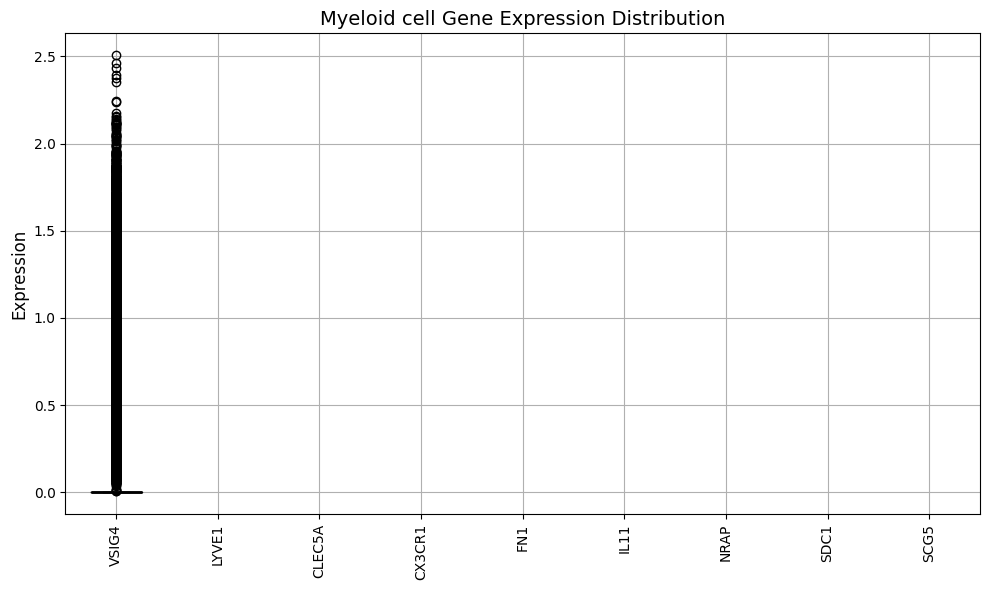

In [31]:
# 유전자별 발현 박스플롯 (검은색 박스/중앙선)
plt.figure(figsize=(10, 6))
ax = df.T.boxplot(
    vert=True,
    rot=90,
    boxprops=dict(color='black'),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', markeredgecolor='black', markerfacecolor='none')
)
plt.title("Myeloid cell Gene Expression Distribution", fontsize=14)
plt.ylabel("Expression", fontsize=12)
plt.tight_layout()
plt.show()

In [33]:
# 2. 메타데이터 로드
meta_path = "/nas/arpa_h_repository/public_data/CRC_Atlas_1/CRC-Atlas-Split/crc-atlas/Deg_data/cellinfo_DA/cellinfo_DA_myeloid_cell_consensus.csv"
meta = pd.read_csv(meta_path, index_col="cell_name")  
meta
# index: cell_name, 컬럼 중 'Group_born'에 MSI/MSS 정보가 들어 있어요

,Group_born,Batch,Group
cell_name,,,
Che_2021-SRR14710630-AAAGATGAGAGGTAGA,MSS,Myeloid cell,MSS_high
Che_2021-SRR14710630-AAAGCAAGTTCAGCGC,MSS,Myeloid cell,MSS_high
Che_2021-SRR14710630-AACCATGTCGTACCGG,MSS,Myeloid cell,MSS_high
Che_2021-SRR14710630-AACGTTGGTCTCCATC,MSS,Myeloid cell,MSS_high
Che_2021-SRR14710630-AAGACCTAGCCCAGCT,MSS,Myeloid cell,MSS_high
...,...,...,...
Zheng_2022-GSM4904246-TTCGAAGGTTCGCTAA,MSS,Myeloid cell,MSS_high
Zheng_2022-GSM4904246-TTCTCAACAAGTAATG,MSS,Myeloid cell,MSS_high
Zheng_2022-GSM4904246-TTGAACGTCATGTCTT,MSS,Myeloid cell,MSS_high


In [34]:
# 2) 전체 셀 개수
total_cells = meta.shape[0]

# 3) MSI vs MSS 셀 개수
group_counts = meta["Group_born"].value_counts()

print(f"전체 셀 개수: {total_cells}")
print("Group_born별 셀 개수:")
print(group_counts)

전체 셀 개수: 48412
Group_born별 셀 개수:
Group_born
MSS    27846
MSI    20566
Name: count, dtype: int64


In [35]:
# 2) 그룹별 셀 ID 분리
msi_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSI"])
mss_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSS"])

# 3) 발현된 셀 개수 계산
expr_counts = pd.DataFrame({
    "msi_count":   (df[msi_cells] > 0).sum(axis=1),
    "mss_count":   (df[mss_cells] > 0).sum(axis=1)
})

# 4) 두 그룹 합 대비 비율 (각 유전자별)
expr_props = expr_counts.div(expr_counts.sum(axis=1), axis=0)
expr_props.columns = ["msi_probability", "mss_prbability"]
expr_props

,msi_probability,mss_prbability
VSIG4,0.07181,0.92819
LYVE1,NaN,NaN
CLEC5A,NaN,NaN
CX3CR1,NaN,NaN
FN1,NaN,NaN
IL11,NaN,NaN
NRAP,NaN,NaN
SDC1,NaN,NaN
SCG5,NaN,NaN


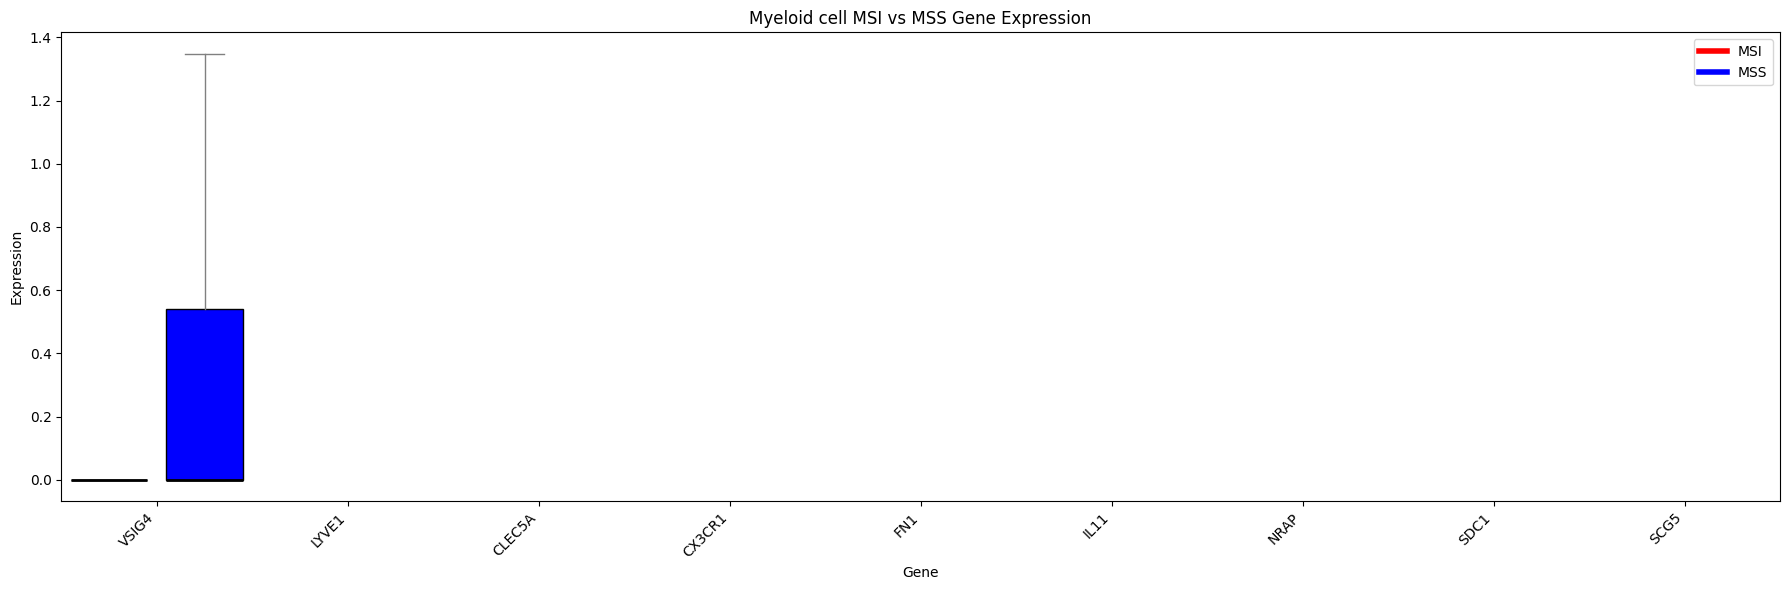

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1) 데이터 로드
matrix_path = "/data/project/arpa_h/raw_data/split/9_genes_matrix/myeloid_filtered_matrix.csv"
df = pd.read_csv(matrix_path, index_col=0)

meta_path = "/nas/arpa_h_repository/public_data/CRC_Atlas_1/CRC-Atlas-Split/crc-atlas/Deg_data/cellinfo_DA/cellinfo_DA_myeloid_cell_consensus.csv"
meta = pd.read_csv(meta_path, index_col="cell_name")

# 2) MSI/MSS 셀 ID 분리
msi_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSI"])
mss_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSS"])

# 3) 유전자 리스트 (인덱스)
genes = df.index.tolist()

# 4) 데이터와 위치 설정
data = []
positions = []
labels = []  # for gene names at center

for i, gene in enumerate(genes):
    # 각 gene마다 MSI 데이터, MSS 데이터 추가
    data.append(df.loc[gene, msi_cells].dropna())
    data.append(df.loc[gene, mss_cells].dropna())
    # 위치: 2*i+1, 2*i+2
    positions.extend([2*i+1, 2*i+2])
    # gene label 위치 중앙(2*i+1.5)
    labels.append((2*i+1 + 2*i+2)/2)

# 5) 박스플롯
# plt.figure(figsize=(2*len(genes), 6))
# box = plt.boxplot(data,
#                   positions=positions,
#                   widths=0.8,
#                   patch_artist=True,
#                   showfliers=False)
# 5) 박스플롯 그리기 (medianprops 추가)
plt.figure(figsize=(2*len(genes), 6))
box = plt.boxplot(
    data,
    positions=positions,
    widths=0.8,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(color='gray'),
    capprops=dict(color='gray')
)

# 6) 색상 지정: MSI 빨강, MSS 파랑
for idx, patch in enumerate(box['boxes']):
    if idx % 2 == 0:      # 짝수 인덱스 → MSI
        patch.set_facecolor('red')
    else:                 # 홀수 인덱스 → MSS
        patch.set_facecolor('blue')

# x축 눈금: gene 이름을 중앙에
plt.xticks(labels, genes, rotation=45, ha='right')

# 8) 범례 추가
red_patch = plt.Line2D([0], [0], color='red', lw=4)
blue_patch = plt.Line2D([0], [0], color='blue', lw=4)
plt.legend([red_patch, blue_patch], ['MSI', 'MSS'], loc='upper right')

plt.xlabel("Gene")
plt.ylabel("Expression")
plt.title("Myeloid cell MSI vs MSS Gene Expression")
        

plt.tight_layout()
plt.show()

## random10

In [46]:
# 1. 데이터 로드
matrix_path = "/data/project/arpa_h/raw_data/split/9_genes_matrix/random10_filtered_matrix.csv"
df = pd.read_csv(matrix_path, index_col=0)  # Unnamed: 0 → gene names
df

,Borras_2023_SMC5-SMC057T-GCTCCTACACGAAGCA,Borras_2023_SMC5-SMC057T-TACCTTACACGTCAGC,Borras_2023_SMC5-SMC071T-GAGTCCGCAGTCGATT,Borras_2023_SMC5-SMC071T-GTGCTTCAGCAGACTG,Borras_2023_SMC5-SMC083T-TGTTCCGGTGGCCCTA,Borras_2023_SMC5-SMC136T-CCCATACCAGGGATTG,Che_2021-SRR14710630-CGGACACCATGTTCCC,Chen_2024-GSM7558371-CCGTTCAGTAGGCATG,Chen_2024-GSM7558472-CATTATCGTTGAGTTC,Chen_2024-GSM7558472-CTGTGCTTCTCATTCA,...,deVries_2023_LUMC-HTO8-AACACGTAGCCACTAT,deVries_2023_LUMC-HTO8-ACACCAAAGATGTAAC,deVries_2023_LUMC-HTO8-ACGCCGATCAAGCCTA,deVries_2023_LUMC-HTO8-AGCTCCTCAAAGTGCG,deVries_2023_LUMC-HTO8-CCATTCGCAGGCAGTA,deVries_2023_LUMC-HTO9-CGACCTTTCTCAACTT,deVries_2023_LUMC-HTO8-CGGAGCTGTGAAAGAG,deVries_2023_LUMC-HTO8-CTCGTCACATAGGATA,deVries_2023_LUMC-HTO8-GCCAAATCAGAGCCAA,deVries_2023_LUMC-HTO8-GGAACTTGTAAGAGAG
SDC1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.574025,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
VSIG4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LYVE1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CLEC5A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CX3CR1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FN1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IL11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NRAP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SCG5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [47]:
# Median 발현값
median_expr = df.median(axis=1, skipna=True)
median_expr

SDC1      0.106627
VSIG4          NaN
LYVE1          NaN
CLEC5A         NaN
CX3CR1         NaN
FN1            NaN
IL11           NaN
NRAP           NaN
SCG5           NaN
dtype: float64

In [48]:
# mean 발현값
mean_expr = df.mean(axis=1, skipna=True)
mean_expr

SDC1      0.162472
VSIG4          NaN
LYVE1          NaN
CLEC5A         NaN
CX3CR1         NaN
FN1            NaN
IL11           NaN
NRAP           NaN
SCG5           NaN
dtype: float64

In [39]:
# NaN을 0으로 치지 않고, 실제 0인 셀만 세기
zero_only = (df == 0)
zero_ratio = zero_only.sum(axis=1) / df.shape[1]
zero_ratio

SDC1      0.336328
VSIG4     0.000000
LYVE1     0.000000
CLEC5A    0.000000
CX3CR1    0.000000
FN1       0.000000
IL11      0.000000
NRAP      0.000000
SCG5      0.000000
dtype: float64

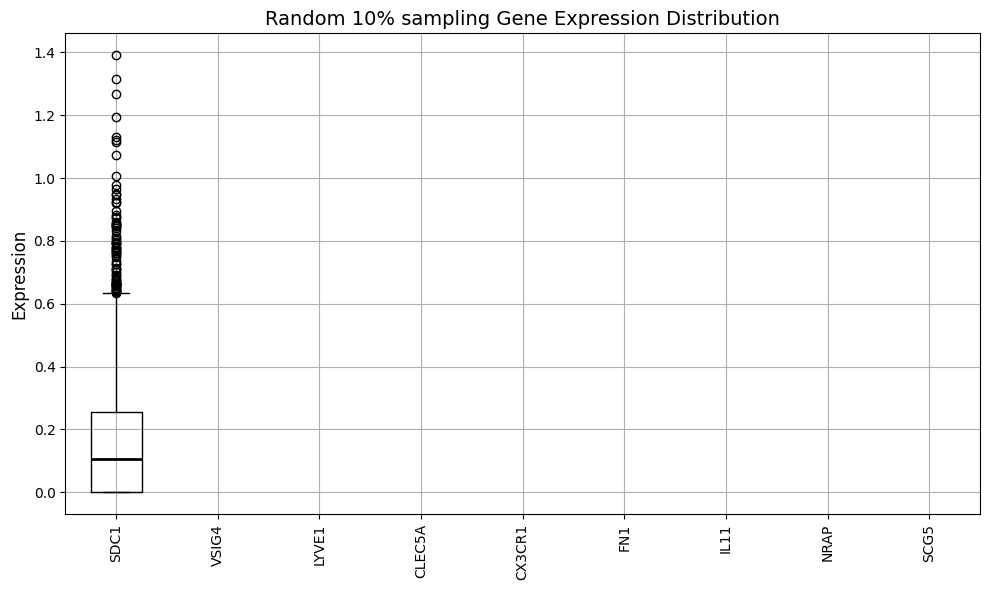

In [40]:
# 유전자별 발현 박스플롯 (검은색 박스/중앙선)
plt.figure(figsize=(10, 6))
ax = df.T.boxplot(
    vert=True,
    rot=90,
    boxprops=dict(color='black'),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', markeredgecolor='black', markerfacecolor='none')
)
plt.title("Random 10% sampling Gene Expression Distribution", fontsize=14)
plt.ylabel("Expression", fontsize=12)
plt.tight_layout()
plt.show()

In [49]:
# 2. 메타데이터 로드
meta_path = "/nas/arpa_h_repository/public_data/CRC_Atlas_1/CRC-Atlas-Split/crc-atlas/Deg_data/cellinfo_DA/cellinfo_DA_random10_consensus.csv"
meta = pd.read_csv(meta_path, index_col="cell_name")  
meta
# index: cell_name, 컬럼 중 'Group_born'에 MSI/MSS 정보가 들어 있어요

,Group_born,Batch,Group
cell_name,,,
Borras_2023_SMC5-SMC057T-GCTCCTACACGAAGCA,MSI,T cell,MSI_high
Borras_2023_SMC5-SMC057T-TACCTTACACGTCAGC,MSI,T cell,MSI_high
Borras_2023_SMC5-SMC071T-GAGTCCGCAGTCGATT,MSI,T cell,MSI_high
Borras_2023_SMC5-SMC071T-GTGCTTCAGCAGACTG,MSI,T cell,MSI_high
Borras_2023_SMC5-SMC083T-TGTTCCGGTGGCCCTA,MSI,T cell,MSI_high
...,...,...,...
deVries_2023_LUMC-HTO9-CGACCTTTCTCAACTT,MSI,T cell,MSI_high
deVries_2023_LUMC-HTO8-CGGAGCTGTGAAAGAG,MSI,T cell,MSI_high
deVries_2023_LUMC-HTO8-CTCGTCACATAGGATA,MSI,T cell,MSI_high


In [50]:
# 2) 전체 셀 개수
total_cells = meta.shape[0]

# 3) MSI vs MSS 셀 개수
group_counts = meta["Group_born"].value_counts()

print(f"전체 셀 개수: {total_cells}")
print("Group_born별 셀 개수:")
print(group_counts)

전체 셀 개수: 2783
Group_born별 셀 개수:
Group_born
MSS    2113
MSI     670
Name: count, dtype: int64


In [51]:
# 2) 그룹별 셀 ID 분리
msi_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSI"])
mss_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSS"])

# 3) 발현된 셀 개수 계산
expr_counts = pd.DataFrame({
    "msi_count":   (df[msi_cells] > 0).sum(axis=1),
    "mss_count":   (df[mss_cells] > 0).sum(axis=1)
})

# 4) 두 그룹 합 대비 비율 (각 유전자별)
expr_props = expr_counts.div(expr_counts.sum(axis=1), axis=0)
expr_props.columns = ["msi_probability", "mss_prbability"]
expr_props

,msi_probability,mss_prbability
SDC1,0.208988,0.791012
VSIG4,NaN,NaN
LYVE1,NaN,NaN
CLEC5A,NaN,NaN
CX3CR1,NaN,NaN
FN1,NaN,NaN
IL11,NaN,NaN
NRAP,NaN,NaN
SCG5,NaN,NaN


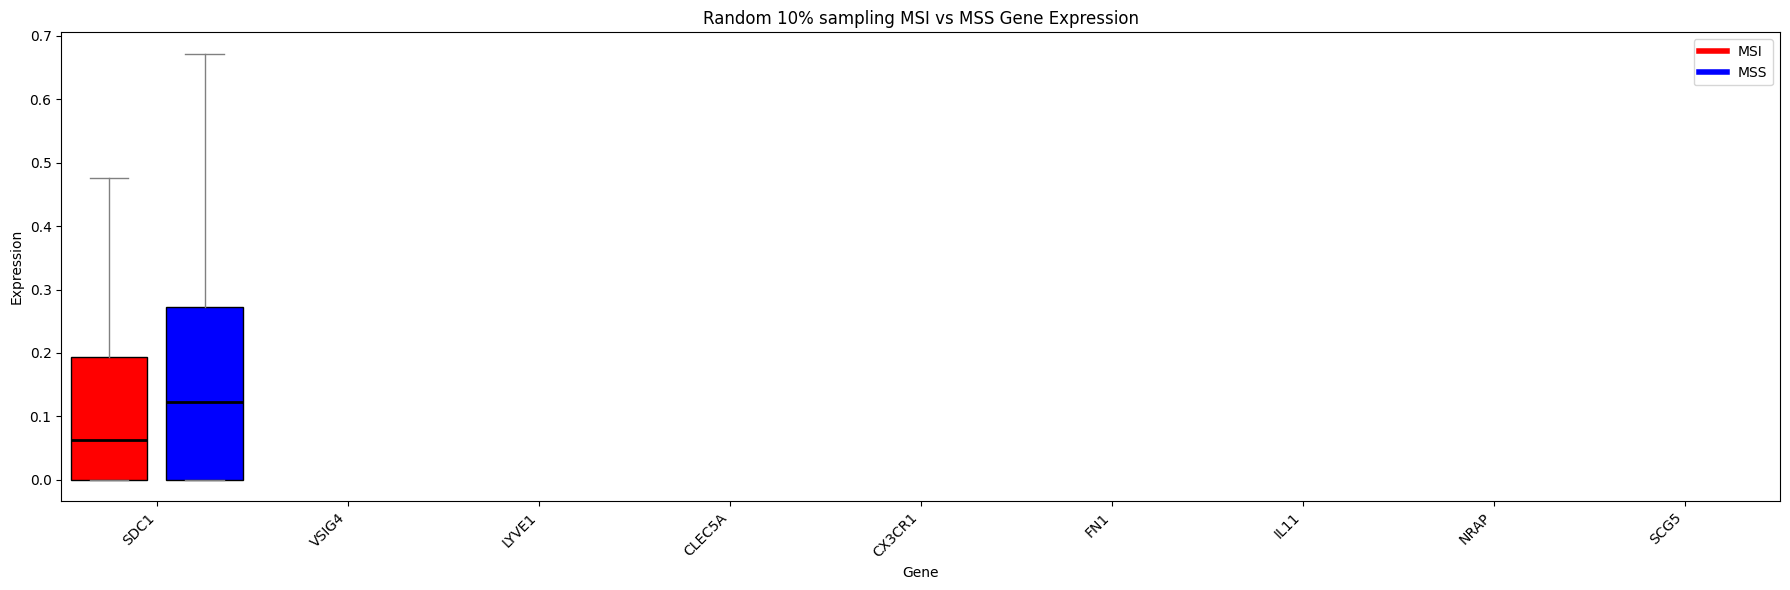

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# 2) MSI/MSS 셀 ID 분리
msi_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSI"])
mss_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSS"])

# 3) 유전자 리스트 (인덱스)
genes = df.index.tolist()

# 4) 데이터와 위치 설정
data = []
positions = []
labels = []  # for gene names at center

for i, gene in enumerate(genes):
    # 각 gene마다 MSI 데이터, MSS 데이터 추가
    data.append(df.loc[gene, msi_cells].dropna())
    data.append(df.loc[gene, mss_cells].dropna())
    # 위치: 2*i+1, 2*i+2
    positions.extend([2*i+1, 2*i+2])
    # gene label 위치 중앙(2*i+1.5)
    labels.append((2*i+1 + 2*i+2)/2)

# 5) 박스플롯
# plt.figure(figsize=(2*len(genes), 6))
# box = plt.boxplot(data,
#                   positions=positions,
#                   widths=0.8,
#                   patch_artist=True,
#                   showfliers=False)
# 5) 박스플롯 그리기 (medianprops 추가)
plt.figure(figsize=(2*len(genes), 6))
box = plt.boxplot(
    data,
    positions=positions,
    widths=0.8,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(color='gray'),
    capprops=dict(color='gray')
)

# 6) 색상 지정: MSI 빨강, MSS 파랑
for idx, patch in enumerate(box['boxes']):
    if idx % 2 == 0:      # 짝수 인덱스 → MSI
        patch.set_facecolor('red')
    else:                 # 홀수 인덱스 → MSS
        patch.set_facecolor('blue')

# x축 눈금: gene 이름을 중앙에
plt.xticks(labels, genes, rotation=45, ha='right')

# 8) 범례 추가
red_patch = plt.Line2D([0], [0], color='red', lw=4)
blue_patch = plt.Line2D([0], [0], color='blue', lw=4)
plt.legend([red_patch, blue_patch], ['MSI', 'MSS'], loc='upper right')

plt.xlabel("Gene")
plt.ylabel("Expression")
plt.title("Random 10% sampling MSI vs MSS Gene Expression")
        

plt.tight_layout()
plt.show()

## Epithelial

In [80]:
# 1. 데이터 로드
matrix_path = "/data/project/arpa_h/raw_data/split/9_genes_matrix/Epithelial_filtered_matrix.csv"
df = pd.read_csv(matrix_path, index_col=0)  # Unnamed: 0 → gene names
df

,Che_2021-SRR14710620-GCAAACTCATGCGCAC,Che_2021-SRR14710616-GTAGGCCAGTCCTCCT,Chen_2024-GSM7558333-CACACCTGTATATCCG,Chen_2024-GSM7558333-CAGTCCTTCTGGCGAC,Chen_2024-GSM7558333-CTCCTAGGTCATCGGC,Chen_2024-GSM7558333-GCAGCCATCGATAGAA,Chen_2024-GSM7558333-GGATTACTCTTAACCT,Chen_2024-GSM7558333-GTTAAGCGTATCACCA,Chen_2024-GSM7558333-TACCTTAAGACAAGCC,Chen_2024-GSM7558334-CAGGTGCCAGACTCGC,...,Zheng_2022-GSM4904243-GCATGCGGTACGAAAT,Zheng_2022-GSM4904243-GCATGTAAGAGACTTA,Zheng_2022-GSM4904243-GCTGCAGCAGCGTCCA,Zheng_2022-GSM4904243-GGATGTTCAGCTGCTG,Zheng_2022-GSM4904243-TGCACCTAGTCTCGGC,Zheng_2022-GSM4904243-TTAGGACTCTTCGGTC,Zheng_2022-GSM4904246-ACGGGCTAGTGAACGC,Zheng_2022-GSM4904246-AGCGTATGTGGCCCTA,Zheng_2022-GSM4904246-CATTATCTCAGCTCTC,Zheng_2022-GSM4904246-CGCTTCAGTATAGGGC
SDC1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.158136,0.38438,0.273071,0.09092,0.27856,0.328507,0.0,0.0,0.185205,0.414519
VSIG4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LYVE1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CLEC5A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CX3CR1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FN1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IL11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NRAP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SCG5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [54]:
# Median 발현값
median_expr = df.median(axis=1, skipna=True)
median_expr

SDC1      0.0
VSIG4     NaN
LYVE1     NaN
CLEC5A    NaN
CX3CR1    NaN
FN1       NaN
IL11      NaN
NRAP      NaN
SCG5      NaN
dtype: float64

In [55]:
# mean 발현값
mean_expr = df.mean(axis=1, skipna=True)
mean_expr

SDC1      0.095194
VSIG4          NaN
LYVE1          NaN
CLEC5A         NaN
CX3CR1         NaN
FN1            NaN
IL11           NaN
NRAP           NaN
SCG5           NaN
dtype: float64

In [56]:
# NaN을 0으로 치지 않고, 실제 0인 셀만 세기
zero_only = (df == 0)
zero_ratio = zero_only.sum(axis=1) / df.shape[1]
zero_ratio

SDC1      0.779218
VSIG4     0.000000
LYVE1     0.000000
CLEC5A    0.000000
CX3CR1    0.000000
FN1       0.000000
IL11      0.000000
NRAP      0.000000
SCG5      0.000000
dtype: float64

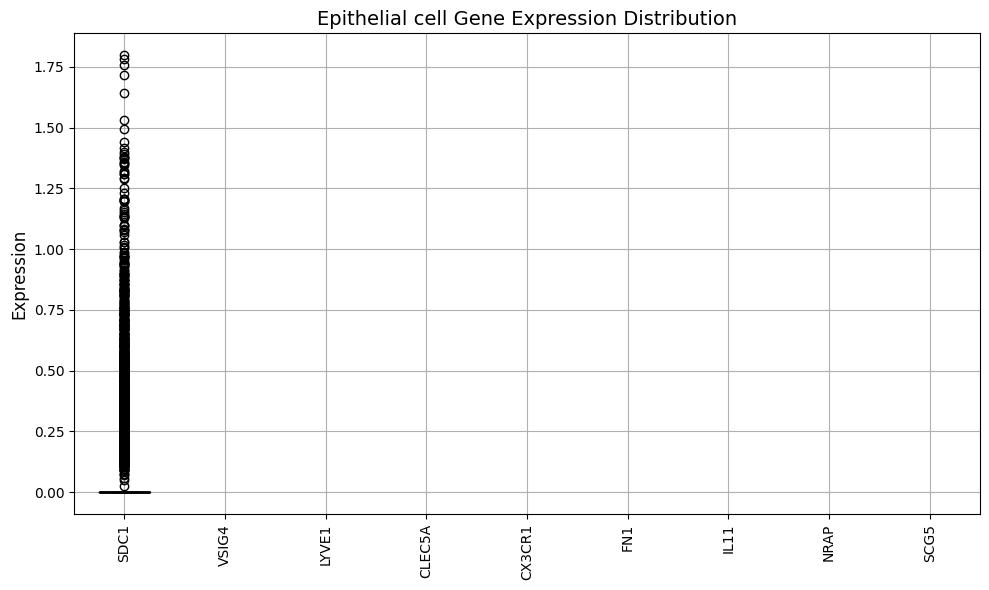

In [81]:
# 유전자별 발현 박스플롯 (검은색 박스/중앙선)
plt.figure(figsize=(10, 6))
ax = df.T.boxplot(
    vert=True,
    rot=90,
    boxprops=dict(color='black'),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', markeredgecolor='black', markerfacecolor='none')
)
plt.title("Epithelial cell Gene Expression Distribution", fontsize=14)
plt.ylabel("Expression", fontsize=12)
plt.tight_layout()
plt.show()

In [82]:
# 2. 메타데이터 로드
meta_path = "/nas/arpa_h_repository/public_data/CRC_Atlas_1/CRC-Atlas-Split/crc-atlas/Deg_data/cellinfo_DA/cellinfo_DA_Epithelial_consensus.csv"
meta = pd.read_csv(meta_path, index_col="Cell")  
meta
# index: cell_name, 컬럼 중 'Group_born'에 MSI/MSS 정보가 들어 있어요

,Group_born,Batch,Group
Cell,,,
Che_2021-SRR14710620-GCAAACTCATGCGCAC,MSS,Epithelial cell,MSS_high
Che_2021-SRR14710616-GTAGGCCAGTCCTCCT,MSS,Epithelial cell,MSS_high
Chen_2024-GSM7558333-CACACCTGTATATCCG,MSS,Epithelial cell,MSI_high
Chen_2024-GSM7558333-CAGTCCTTCTGGCGAC,MSS,Epithelial cell,MSI_high
Chen_2024-GSM7558333-CTCCTAGGTCATCGGC,MSS,Epithelial cell,MSI_high
...,...,...,...
Zheng_2022-GSM4904243-TTAGGACTCTTCGGTC,MSS,Epithelial cell,MSS_high
Zheng_2022-GSM4904246-ACGGGCTAGTGAACGC,MSS,Epithelial cell,MSS_high
Zheng_2022-GSM4904246-AGCGTATGTGGCCCTA,MSS,Epithelial cell,MSS_high


In [60]:
# 2) 전체 셀 개수
total_cells = meta.shape[0]

# 3) MSI vs MSS 셀 개수
group_counts = meta["Group_born"].value_counts()

print(f"전체 셀 개수: {total_cells}")
print("Group_born별 셀 개수:")
print(group_counts)

전체 셀 개수: 4937
Group_born별 셀 개수:
Group_born
MSS    3219
MSI    1718
Name: count, dtype: int64


In [83]:
# 2) 그룹별 셀 ID 분리
msi_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSI"])
mss_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSS"])

# 3) 발현된 셀 개수 계산
expr_counts = pd.DataFrame({
    "msi_count":   (df[msi_cells] > 0).sum(axis=1),
    "mss_count":   (df[mss_cells] > 0).sum(axis=1)
})

# 4) 두 그룹 합 대비 비율 (각 유전자별)
expr_props = expr_counts.div(expr_counts.sum(axis=1), axis=0)
expr_props.columns = ["msi_probability", "mss_prbability"]
expr_props

,msi_probability,mss_prbability
SDC1,0.324771,0.675229
VSIG4,NaN,NaN
LYVE1,NaN,NaN
CLEC5A,NaN,NaN
CX3CR1,NaN,NaN
FN1,NaN,NaN
IL11,NaN,NaN
NRAP,NaN,NaN
SCG5,NaN,NaN


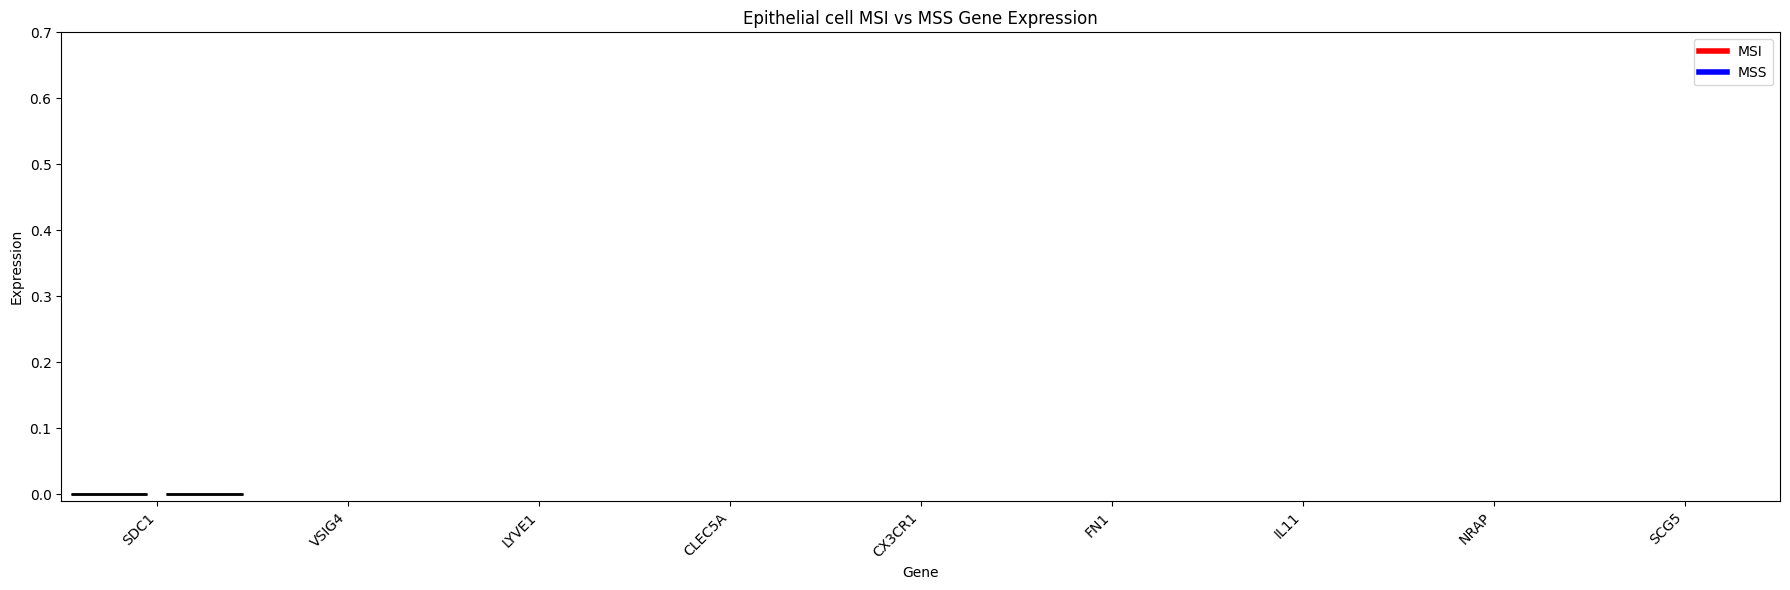

In [85]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# 2) MSI/MSS 셀 ID 분리
msi_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSI"])
mss_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSS"])

# 3) 유전자 리스트 (인덱스)
genes = df.index.tolist()

# 4) 데이터와 위치 설정
data = []
positions = []
labels = []  # for gene names at center

for i, gene in enumerate(genes):
    # 각 gene마다 MSI 데이터, MSS 데이터 추가
    data.append(df.loc[gene, msi_cells].dropna())
    data.append(df.loc[gene, mss_cells].dropna())
    # 위치: 2*i+1, 2*i+2
    positions.extend([2*i+1, 2*i+2])
    # gene label 위치 중앙(2*i+1.5)
    labels.append((2*i+1 + 2*i+2)/2)

# 5) 박스플롯
# plt.figure(figsize=(2*len(genes), 6))
# box = plt.boxplot(data,
#                   positions=positions,
#                   widths=0.8,
#                   patch_artist=True,
#                   showfliers=False)
# 5) 박스플롯 그리기 (medianprops 추가)
plt.figure(figsize=(2*len(genes), 6))
box = plt.boxplot(
    data,
    positions=positions,
    widths=0.8,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(color='gray'),
    capprops=dict(color='gray')
)

# 6) 색상 지정: MSI 빨강, MSS 파랑
for idx, patch in enumerate(box['boxes']):
    if idx % 2 == 0:      # 짝수 인덱스 → MSI
        patch.set_facecolor('red')
    else:                 # 홀수 인덱스 → MSS
        patch.set_facecolor('blue')

# x축 눈금: gene 이름을 중앙에
plt.xticks(labels, genes, rotation=45, ha='right')

# 8) 범례 추가
red_patch = plt.Line2D([0], [0], color='red', lw=4)
blue_patch = plt.Line2D([0], [0], color='blue', lw=4)
plt.legend([red_patch, blue_patch], ['MSI', 'MSS'], loc='upper right')

plt.xlabel("Gene")
plt.ylabel("Expression")
plt.title("Epithelial cell MSI vs MSS Gene Expression")
        
plt.ylim(-0.01, 0.7)
plt.tight_layout()
plt.show()

## Neutrophil

In [87]:
# 1. 데이터 로드
matrix_path = "/data/project/arpa_h/raw_data/split/9_genes_matrix/neutrophil_filtered_matrix.csv"
df = pd.read_csv(matrix_path, index_col=0)  # Unnamed: 0 → gene names
df

,Che_2021-SRR14710629-GGGATGAGTTGACGTT,Chen_2024-GSM7558371-GCAAACTGTCAGTGGA,Chen_2024-GSM7558464-GTCACGGCACAACGCC,Chen_2024-GSM7558510-TGAGCCGGTTTGTTTC,Chen_2024-GSM7558567-AAAGTAGCATGGATGG,Chen_2024-GSM7558567-AAGTCTGGTCTCTTTA,Chen_2024-GSM7558567-ACAGCTAAGCTAACAA,Chen_2024-GSM7558567-ACCAGTAAGCAGACTG,Chen_2024-GSM7558567-ACTTTCAGTACGACCC,Chen_2024-GSM7558567-AGAGTGGTCTCGAGTA,...,Wu_2022_CD45Pos-P19_Colon_T-CTACTATTCTCCACTG-1,Wu_2022_CD45Pos-P19_Colon_T-GATGGAGCACAGGATG-1,Wu_2022_CD45Pos-P19_Colon_T-TCACACCTCGTTCCCA-1,Wu_2022_CD45Pos-P19_Colon_T-TCAGGGCTCCCAAGTA-1,Wu_2022_CD45Pos-P19_Colon_T-TTGAGTGCAAGCGAGT-1,Wu_2022_CD45Pos-P19_Colon_T-TTGCATTTCCGAGAAG-1,Wu_2022_CD45Pos-P14_Liver_T-ACAGGGAAGACATCCT-1,Zheng_2022-GSM4904238-AAGGTTCAGTGGCACA,Zheng_2022-GSM4904238-TCAATCTAGCAGCGTA,Zheng_2022-GSM4904245-AACTGGTAGGCCCTCA
VSIG4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LYVE1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CLEC5A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CX3CR1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FN1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IL11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NRAP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SDC1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SCG5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [64]:
# Median 발현값
median_expr = df.median(axis=1, skipna=True)
median_expr

VSIG4    NaN
LYVE1    NaN
CLEC5A   NaN
CX3CR1   NaN
FN1      NaN
IL11     NaN
NRAP     NaN
SDC1     NaN
SCG5     NaN
dtype: float64

In [65]:
# mean 발현값
mean_expr = df.mean(axis=1, skipna=True)
mean_expr

VSIG4    NaN
LYVE1    NaN
CLEC5A   NaN
CX3CR1   NaN
FN1      NaN
IL11     NaN
NRAP     NaN
SDC1     NaN
SCG5     NaN
dtype: float64

In [66]:
# NaN을 0으로 치지 않고, 실제 0인 셀만 세기
zero_only = (df == 0)
zero_ratio = zero_only.sum(axis=1) / df.shape[1]
zero_ratio

VSIG4     0.0
LYVE1     0.0
CLEC5A    0.0
CX3CR1    0.0
FN1       0.0
IL11      0.0
NRAP      0.0
SDC1      0.0
SCG5      0.0
dtype: float64

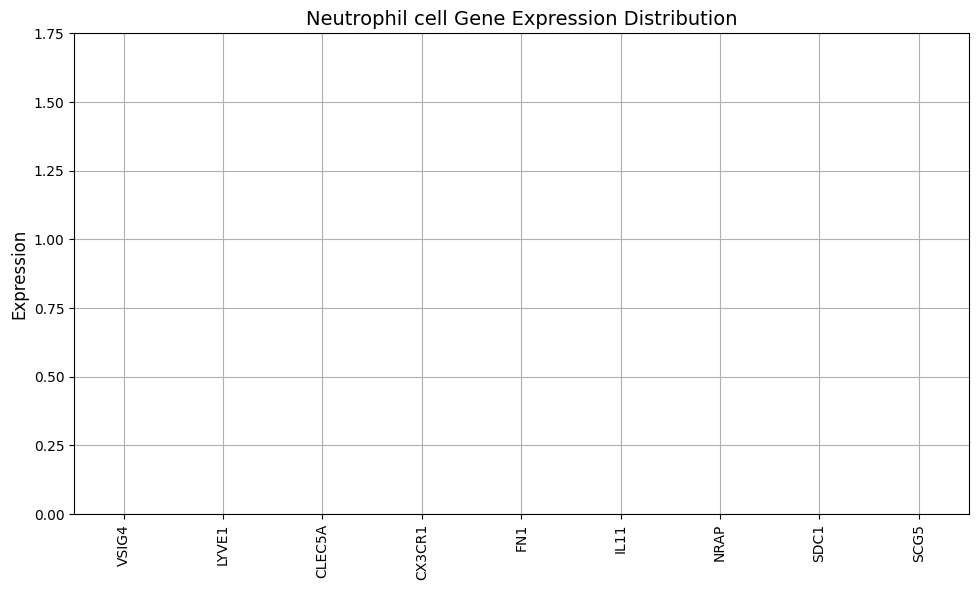

In [71]:
# 유전자별 발현 박스플롯 (검은색 박스/중앙선)
plt.figure(figsize=(10, 6))
ax = df.T.boxplot(
    vert=True,
    rot=90,
    boxprops=dict(color='black'),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', markeredgecolor='black', markerfacecolor='none')
)
plt.title("Neutrophil cell Gene Expression Distribution", fontsize=14)
plt.ylabel("Expression", fontsize=12)
plt.tight_layout()
# y축 범위 및 눈금 간격 설정
plt.ylim(0, 1.75)
plt.yticks(np.arange(0, 1.75 + 0.001, 0.25))
plt.show()

In [88]:
# 2. 메타데이터 로드
meta_path = "/nas/arpa_h_repository/public_data/CRC_Atlas_1/CRC-Atlas-Split/crc-atlas/Deg_data/cellinfo_DA/cellinfo_DA_neutrophil_consensus.csv"
meta = pd.read_csv(meta_path, index_col="cell_name")  
meta
# index: cell_name, 컬럼 중 'Group_born'에 MSI/MSS 정보가 들어 있어요

,Group_born,Batch,Group
cell_name,,,
Che_2021-SRR14710629-GGGATGAGTTGACGTT,MSS,Neutrophil,MSI_high
Chen_2024-GSM7558371-GCAAACTGTCAGTGGA,MSI,Neutrophil,MSI_high
Chen_2024-GSM7558464-GTCACGGCACAACGCC,MSI,Neutrophil,MSI_high
Chen_2024-GSM7558510-TGAGCCGGTTTGTTTC,MSI,Neutrophil,MSI_high
Chen_2024-GSM7558567-AAAGTAGCATGGATGG,MSI,Neutrophil,MSI_high
...,...,...,...
Wu_2022_CD45Pos-P19_Colon_T-TTGCATTTCCGAGAAG-1,MSS,Neutrophil,MSI_high
Wu_2022_CD45Pos-P14_Liver_T-ACAGGGAAGACATCCT-1,MSS,Neutrophil,MSI_high
Zheng_2022-GSM4904238-AAGGTTCAGTGGCACA,MSS,Neutrophil,MSI_high


In [75]:
# 2) 전체 셀 개수
total_cells = meta.shape[0]

# 3) MSI vs MSS 셀 개수
group_counts = meta["Group_born"].value_counts()

print(f"전체 셀 개수: {total_cells}")
print("Group_born별 셀 개수:")
print(group_counts)

전체 셀 개수: 12276
Group_born별 셀 개수:
Group_born
MSS    10611
MSI     1665
Name: count, dtype: int64


In [89]:
# 2) 그룹별 셀 ID 분리
msi_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSI"])
mss_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSS"])

# 3) 발현된 셀 개수 계산
expr_counts = pd.DataFrame({
    "msi_count":   (df[msi_cells] > 0).sum(axis=1),
    "mss_count":   (df[mss_cells] > 0).sum(axis=1)
})

# 4) 두 그룹 합 대비 비율 (각 유전자별)
expr_props = expr_counts.div(expr_counts.sum(axis=1), axis=0)
expr_props.columns = ["msi_probability", "mss_prbability"]
expr_props

,msi_probability,mss_prbability
VSIG4,NaN,NaN
LYVE1,NaN,NaN
CLEC5A,NaN,NaN
CX3CR1,NaN,NaN
FN1,NaN,NaN
IL11,NaN,NaN
NRAP,NaN,NaN
SDC1,NaN,NaN
SCG5,NaN,NaN


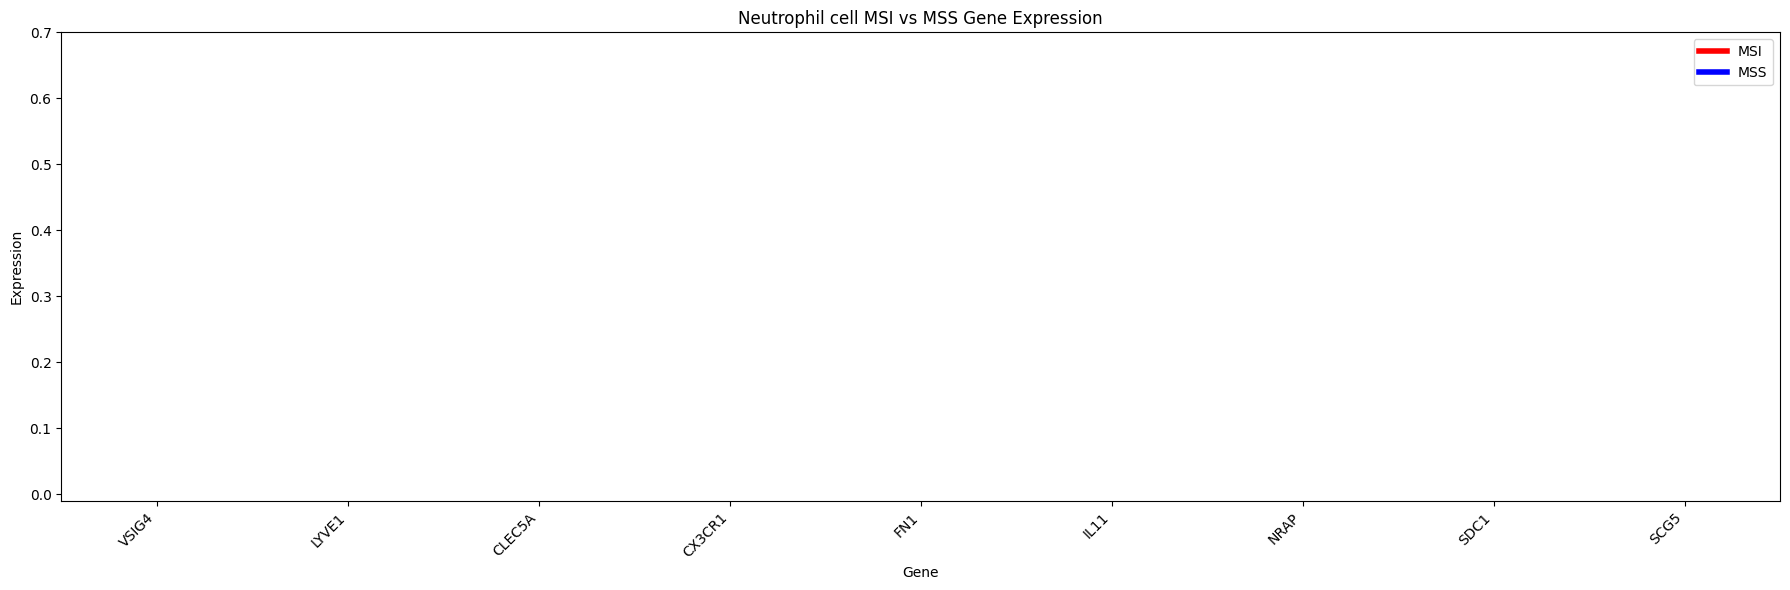

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# 2) MSI/MSS 셀 ID 분리
msi_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSI"])
mss_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSS"])

# 3) 유전자 리스트 (인덱스)
genes = df.index.tolist()

# 4) 데이터와 위치 설정
data = []
positions = []
labels = []  # for gene names at center

for i, gene in enumerate(genes):
    # 각 gene마다 MSI 데이터, MSS 데이터 추가
    data.append(df.loc[gene, msi_cells].dropna())
    data.append(df.loc[gene, mss_cells].dropna())
    # 위치: 2*i+1, 2*i+2
    positions.extend([2*i+1, 2*i+2])
    # gene label 위치 중앙(2*i+1.5)
    labels.append((2*i+1 + 2*i+2)/2)

# 5) 박스플롯
# plt.figure(figsize=(2*len(genes), 6))
# box = plt.boxplot(data,
#                   positions=positions,
#                   widths=0.8,
#                   patch_artist=True,
#                   showfliers=False)
# 5) 박스플롯 그리기 (medianprops 추가)
plt.figure(figsize=(2*len(genes), 6))
box = plt.boxplot(
    data,
    positions=positions,
    widths=0.8,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(color='gray'),
    capprops=dict(color='gray')
)

# 6) 색상 지정: MSI 빨강, MSS 파랑
for idx, patch in enumerate(box['boxes']):
    if idx % 2 == 0:      # 짝수 인덱스 → MSI
        patch.set_facecolor('red')
    else:                 # 홀수 인덱스 → MSS
        patch.set_facecolor('blue')

# x축 눈금: gene 이름을 중앙에
plt.xticks(labels, genes, rotation=45, ha='right')

# 8) 범례 추가
red_patch = plt.Line2D([0], [0], color='red', lw=4)
blue_patch = plt.Line2D([0], [0], color='blue', lw=4)
plt.legend([red_patch, blue_patch], ['MSI', 'MSS'], loc='upper right')

plt.xlabel("Gene")
plt.ylabel("Expression")
plt.title("Neutrophil cell MSI vs MSS Gene Expression")
        
plt.ylim(-0.01, 0.7)
plt.tight_layout()
plt.show()

## Stromal

In [92]:
# 1. 데이터 로드
matrix_path = "/data/project/arpa_h/raw_data/split/9_genes_matrix/stromal_filtered_matrix.csv"
df = pd.read_csv(matrix_path, index_col=0)  # Unnamed: 0 → gene names
df

,Che_2021-SRR14710630-AACCATGGTTTAGCTG,Che_2021-SRR14710630-AAGGTTCAGACCTTTG,Che_2021-SRR14710630-AAGGTTCTCGGCTACG,Che_2021-SRR14710630-ACTGAGTTCACCGTAA,Che_2021-SRR14710630-ACTGTCCAGCCACGCT,Che_2021-SRR14710630-AGAATAGTCTCTGAGA,Che_2021-SRR14710630-AGAGCTTGTGCAGACA,Che_2021-SRR14710630-AGCGGTCTCGGCGCAT,Che_2021-SRR14710630-AGCTTGACATCCCATC,Che_2021-SRR14710630-ATCATGGGTCTCCACT,...,Zheng_2022-GSM4904240-ACCTTTACATGTCCTC,Zheng_2022-GSM4904240-AGGTCCGTCTTAGCCC,Zheng_2022-GSM4904240-CATCAGATCTACCTGC,Zheng_2022-GSM4904240-GGATTACGTATGGTTC,Zheng_2022-GSM4904240-GTGGGTCAGAACAACT,Zheng_2022-GSM4904240-TCCACACTCACTCCTG,Zheng_2022-GSM4904240-TTTGCGCAGCTAGCCC,Zheng_2022-GSM4904241-CTCTAATTCCGAAGAG,Zheng_2022-GSM4904241-GAACGGAGTCATCGGC,Zheng_2022-GSM4904241-TCTTTCCGTAATTGGA
FN1,2.157984,2.416717,2.447539,1.481045,1.099523,0.0,1.970887,0.81978,2.472333,2.487461,...,2.22989,1.844384,2.592423,1.065516,2.511851,1.97973,2.613234,1.934125,1.707951,1.536022
VSIG4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LYVE1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CLEC5A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CX3CR1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IL11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NRAP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SDC1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SCG5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [93]:
# Median 발현값
median_expr = df.median(axis=1, skipna=True)
median_expr

FN1       0.610251
VSIG4          NaN
LYVE1          NaN
CLEC5A         NaN
CX3CR1         NaN
IL11           NaN
NRAP           NaN
SDC1           NaN
SCG5           NaN
dtype: float64

In [94]:
# mean 발현값
mean_expr = df.mean(axis=1, skipna=True)
mean_expr

FN1       0.84888
VSIG4         NaN
LYVE1         NaN
CLEC5A        NaN
CX3CR1        NaN
IL11          NaN
NRAP          NaN
SDC1          NaN
SCG5          NaN
dtype: float64

In [95]:
# NaN을 0으로 치지 않고, 실제 0인 셀만 세기
zero_only = (df == 0)
zero_ratio = zero_only.sum(axis=1) / df.shape[1]
zero_ratio

FN1       0.386476
VSIG4     0.000000
LYVE1     0.000000
CLEC5A    0.000000
CX3CR1    0.000000
IL11      0.000000
NRAP      0.000000
SDC1      0.000000
SCG5      0.000000
dtype: float64

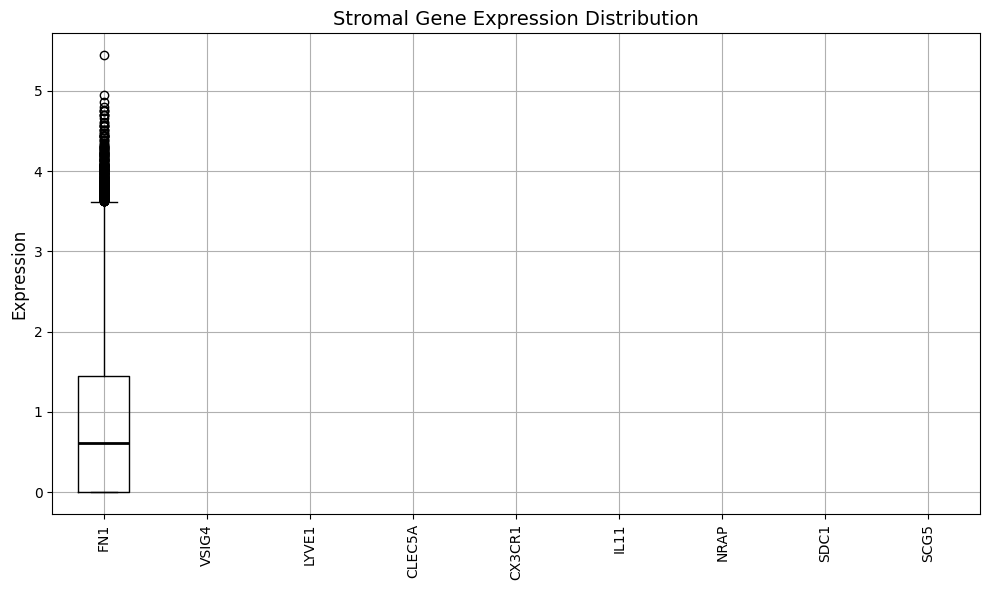

In [96]:
# 유전자별 발현 박스플롯 (검은색 박스/중앙선)
plt.figure(figsize=(10, 6))
ax = df.T.boxplot(
    vert=True,
    rot=90,
    boxprops=dict(color='black'),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', markeredgecolor='black', markerfacecolor='none')
)
plt.title("Stromal Gene Expression Distribution", fontsize=14)
plt.ylabel("Expression", fontsize=12)
plt.tight_layout()
plt.show()

In [97]:
# 2. 메타데이터 로드
meta_path = "/nas/arpa_h_repository/public_data/CRC_Atlas_1/CRC-Atlas-Split/crc-atlas/Deg_data/cellinfo_DA/cellinfo_DA_stromal_consensus.csv"
meta = pd.read_csv(meta_path, index_col="cell_name")  
meta
# index: cell_name, 컬럼 중 'Group_born'에 MSI/MSS 정보가 들어 있어요

,Group_born,Batch,Group
cell_name,,,
Che_2021-SRR14710630-AACCATGGTTTAGCTG,MSS,Stromal cell,MSS_high
Che_2021-SRR14710630-AAGGTTCAGACCTTTG,MSS,Stromal cell,MSS_high
Che_2021-SRR14710630-AAGGTTCTCGGCTACG,MSS,Stromal cell,MSS_high
Che_2021-SRR14710630-ACTGAGTTCACCGTAA,MSS,Stromal cell,MSS_high
Che_2021-SRR14710630-ACTGTCCAGCCACGCT,MSS,Stromal cell,MSS_high
...,...,...,...
Zheng_2022-GSM4904240-TCCACACTCACTCCTG,MSS,Stromal cell,MSI_high
Zheng_2022-GSM4904240-TTTGCGCAGCTAGCCC,MSS,Stromal cell,MSI_high
Zheng_2022-GSM4904241-CTCTAATTCCGAAGAG,MSS,Stromal cell,MSI_high


In [98]:
# 2) 전체 셀 개수
total_cells = meta.shape[0]

# 3) MSI vs MSS 셀 개수
group_counts = meta["Group_born"].value_counts()

print(f"전체 셀 개수: {total_cells}")
print("Group_born별 셀 개수:")
print(group_counts)

전체 셀 개수: 41009
Group_born별 셀 개수:
Group_born
MSS    26205
MSI    14804
Name: count, dtype: int64


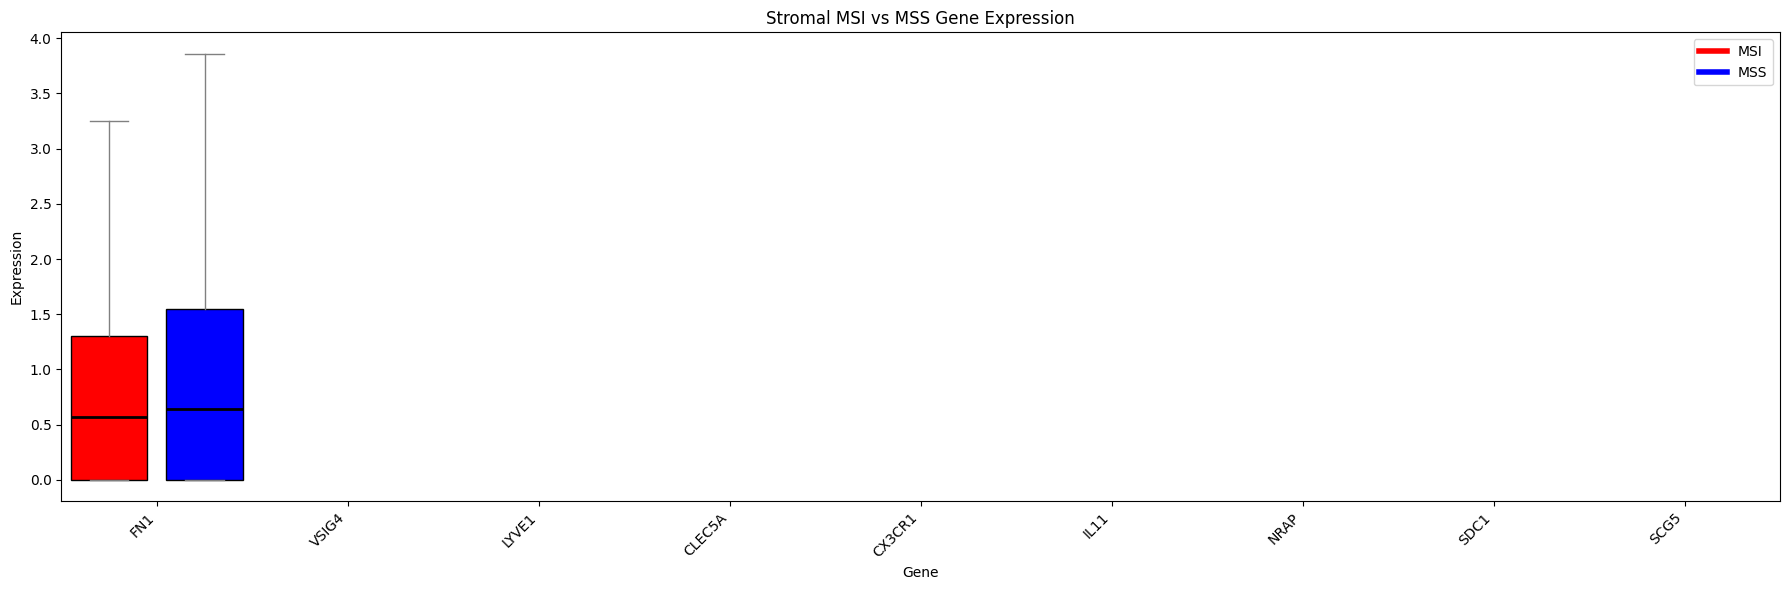

In [99]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# 2) MSI/MSS 셀 ID 분리
msi_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSI"])
mss_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSS"])

# 3) 유전자 리스트 (인덱스)
genes = df.index.tolist()

# 4) 데이터와 위치 설정
data = []
positions = []
labels = []  # for gene names at center

for i, gene in enumerate(genes):
    # 각 gene마다 MSI 데이터, MSS 데이터 추가
    data.append(df.loc[gene, msi_cells].dropna())
    data.append(df.loc[gene, mss_cells].dropna())
    # 위치: 2*i+1, 2*i+2
    positions.extend([2*i+1, 2*i+2])
    # gene label 위치 중앙(2*i+1.5)
    labels.append((2*i+1 + 2*i+2)/2)

# 5) 박스플롯
# plt.figure(figsize=(2*len(genes), 6))
# box = plt.boxplot(data,
#                   positions=positions,
#                   widths=0.8,
#                   patch_artist=True,
#                   showfliers=False)
# 5) 박스플롯 그리기 (medianprops 추가)
plt.figure(figsize=(2*len(genes), 6))
box = plt.boxplot(
    data,
    positions=positions,
    widths=0.8,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(color='gray'),
    capprops=dict(color='gray')
)

# 6) 색상 지정: MSI 빨강, MSS 파랑
for idx, patch in enumerate(box['boxes']):
    if idx % 2 == 0:      # 짝수 인덱스 → MSI
        patch.set_facecolor('red')
    else:                 # 홀수 인덱스 → MSS
        patch.set_facecolor('blue')

# x축 눈금: gene 이름을 중앙에
plt.xticks(labels, genes, rotation=45, ha='right')

# 8) 범례 추가
red_patch = plt.Line2D([0], [0], color='red', lw=4)
blue_patch = plt.Line2D([0], [0], color='blue', lw=4)
plt.legend([red_patch, blue_patch], ['MSI', 'MSS'], loc='upper right')

plt.xlabel("Gene")
plt.ylabel("Expression")
plt.title("Stromal MSI vs MSS Gene Expression")
        

plt.tight_layout()
plt.show()

## Mast

In [100]:
# 1. 데이터 로드
matrix_path = "/data/project/arpa_h/raw_data/split/9_genes_matrix/mast_filtered_matrix.csv"
df = pd.read_csv(matrix_path, index_col=0)  # Unnamed: 0 → gene names
df

,Che_2021-SRR14710623-GCAAACTTCACGCATA,Che_2021-SRR14710620-ACACCGGAGGATGGTC,Che_2021-SRR14710620-AGCATACCAGTATGCT,Che_2021-SRR14710620-AGCGTCGGTGACTACT,Che_2021-SRR14710620-CAAGAAATCCTTCAAT,Che_2021-SRR14710620-CGCCAAGAGATCGGGT,Che_2021-SRR14710620-CGTCAGGGTACTTCTT,Che_2021-SRR14710620-CTACATTGTAGCGTCC,Che_2021-SRR14710620-CTGCTGTAGCCTTGAT,Che_2021-SRR14710620-GCTGCTTAGTGATCGG,...,Zhang_2020_10X_CD45Pos-GSM4405628_P0410_L31-CGTGTAACAACACCCG,Zhang_2020_10X_CD45Pos-GSM4405628_P0410_L31-CGTTAGAGTGCACTTA,Zhang_2020_10X_CD45Pos-GSM4405628_P0410_L31-CGTTCTGAGCTCTCGG,Zhang_2020_10X_CD45Pos-GSM4405628_P0410_L31-CTACCCAAGTCTCGGC,Zhang_2020_10X_CD45Pos-GSM4405628_P0410_L31-GATCAGTAGAGCCTAG,Zhang_2020_10X_CD45Pos-GSM4405628_P0410_L31-GGCTCGAAGCGATCCC,Zhang_2020_10X_CD45Pos-GSM4405628_P0410_L31-TTAGGCACACCTCGGA,Zhang_2020_10X_CD45Pos-GSM4405628_P0410_L32-CGGAGTCTCATGTCTT,Zhang_2020_10X_CD45Pos-GSM4405628_P0410_L32-GACTGCGAGTTAGGTA,Zhang_2020_10X_CD45Pos-GSM4405628_P0410_L32-TCGCGTTTCCTAGAAC
VSIG4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LYVE1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CLEC5A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CX3CR1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FN1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IL11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NRAP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SDC1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SCG5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [101]:
# Median 발현값
median_expr = df.median(axis=1, skipna=True)
median_expr

VSIG4    NaN
LYVE1    NaN
CLEC5A   NaN
CX3CR1   NaN
FN1      NaN
IL11     NaN
NRAP     NaN
SDC1     NaN
SCG5     NaN
dtype: float64

In [102]:
# mean 발현값
mean_expr = df.mean(axis=1, skipna=True)
mean_expr

VSIG4    NaN
LYVE1    NaN
CLEC5A   NaN
CX3CR1   NaN
FN1      NaN
IL11     NaN
NRAP     NaN
SDC1     NaN
SCG5     NaN
dtype: float64

In [103]:
# NaN을 0으로 치지 않고, 실제 0인 셀만 세기
zero_only = (df == 0)
zero_ratio = zero_only.sum(axis=1) / df.shape[1]
zero_ratio

VSIG4     0.0
LYVE1     0.0
CLEC5A    0.0
CX3CR1    0.0
FN1       0.0
IL11      0.0
NRAP      0.0
SDC1      0.0
SCG5      0.0
dtype: float64

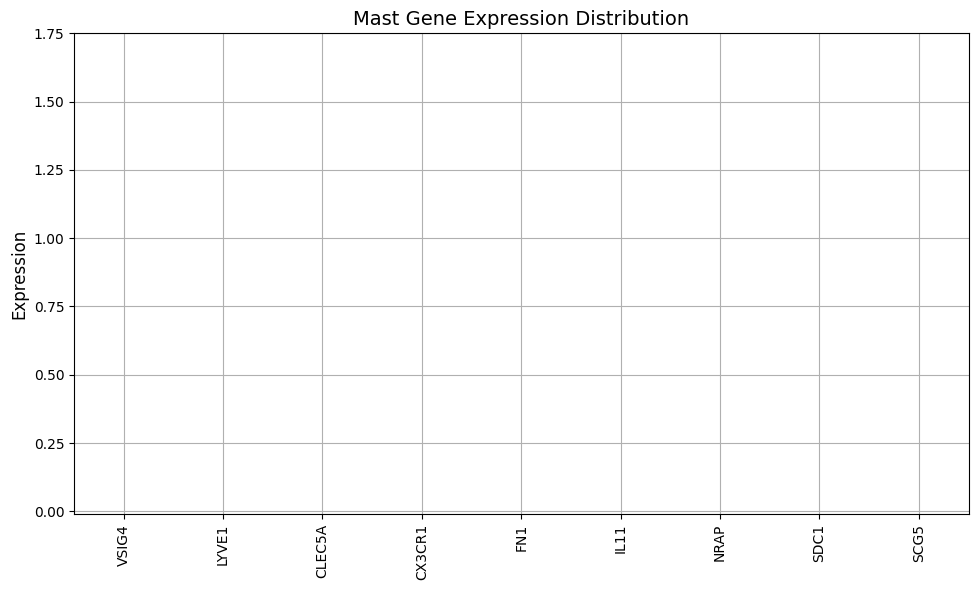

In [106]:
# 유전자별 발현 박스플롯 (검은색 박스/중앙선)
plt.figure(figsize=(10, 6))
ax = df.T.boxplot(
    vert=True,
    rot=90,
    boxprops=dict(color='black'),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', markeredgecolor='black', markerfacecolor='none')
)
plt.title("Mast Gene Expression Distribution", fontsize=14)
plt.ylabel("Expression", fontsize=12)
plt.tight_layout()
plt.ylim(-0.01, 1.75)
plt.yticks(np.arange(0, 1.75 + 0.001, 0.25))
plt.show()

In [108]:
# 2. 메타데이터 로드
meta_path = "/nas/arpa_h_repository/public_data/CRC_Atlas_1/CRC-Atlas-Split/crc-atlas/Deg_data/cellinfo_DA/cellinfo_DA_mast_cell_consensus.csv"
meta = pd.read_csv(meta_path, index_col="cell_name")  
meta
# index: cell_name, 컬럼 중 'Group_born'에 MSI/MSS 정보가 들어 있어요

,Group_born,Batch,Group
cell_name,,,
Che_2021-SRR14710623-GCAAACTTCACGCATA,MSS,Mast cell,MSS_high
Che_2021-SRR14710620-ACACCGGAGGATGGTC,MSS,Mast cell,MSS_high
Che_2021-SRR14710620-AGCATACCAGTATGCT,MSS,Mast cell,MSS_high
Che_2021-SRR14710620-AGCGTCGGTGACTACT,MSS,Mast cell,MSS_high
Che_2021-SRR14710620-CAAGAAATCCTTCAAT,MSS,Mast cell,MSS_high
...,...,...,...
Zhang_2020_10X_CD45Pos-GSM4405628_P0410_L31-GGCTCGAAGCGATCCC,MSS,Mast cell,MSS_high
Zhang_2020_10X_CD45Pos-GSM4405628_P0410_L31-TTAGGCACACCTCGGA,MSS,Mast cell,MSS_high
Zhang_2020_10X_CD45Pos-GSM4405628_P0410_L32-CGGAGTCTCATGTCTT,MSS,Mast cell,MSS_high


In [109]:
# 2) 전체 셀 개수
total_cells = meta.shape[0]

# 3) MSI vs MSS 셀 개수
group_counts = meta["Group_born"].value_counts()

print(f"전체 셀 개수: {total_cells}")
print("Group_born별 셀 개수:")
print(group_counts)

전체 셀 개수: 3086
Group_born별 셀 개수:
Group_born
MSS    2261
MSI     825
Name: count, dtype: int64


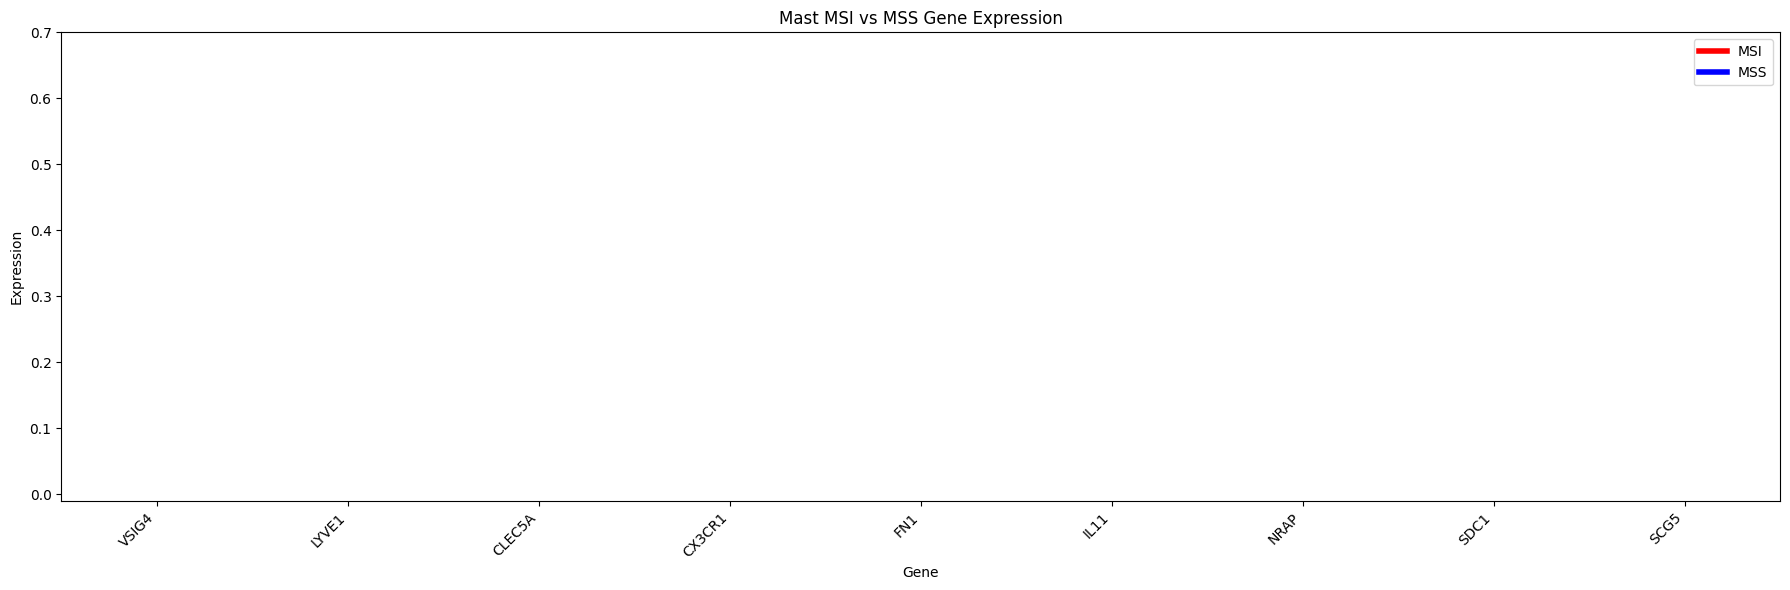

In [111]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# 2) MSI/MSS 셀 ID 분리
msi_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSI"])
mss_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSS"])

# 3) 유전자 리스트 (인덱스)
genes = df.index.tolist()

# 4) 데이터와 위치 설정
data = []
positions = []
labels = []  # for gene names at center

for i, gene in enumerate(genes):
    # 각 gene마다 MSI 데이터, MSS 데이터 추가
    data.append(df.loc[gene, msi_cells].dropna())
    data.append(df.loc[gene, mss_cells].dropna())
    # 위치: 2*i+1, 2*i+2
    positions.extend([2*i+1, 2*i+2])
    # gene label 위치 중앙(2*i+1.5)
    labels.append((2*i+1 + 2*i+2)/2)

# 5) 박스플롯
# plt.figure(figsize=(2*len(genes), 6))
# box = plt.boxplot(data,
#                   positions=positions,
#                   widths=0.8,
#                   patch_artist=True,
#                   showfliers=False)
# 5) 박스플롯 그리기 (medianprops 추가)
plt.figure(figsize=(2*len(genes), 6))
box = plt.boxplot(
    data,
    positions=positions,
    widths=0.8,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(color='gray'),
    capprops=dict(color='gray')
)

# 6) 색상 지정: MSI 빨강, MSS 파랑
for idx, patch in enumerate(box['boxes']):
    if idx % 2 == 0:      # 짝수 인덱스 → MSI
        patch.set_facecolor('red')
    else:                 # 홀수 인덱스 → MSS
        patch.set_facecolor('blue')

# x축 눈금: gene 이름을 중앙에
plt.xticks(labels, genes, rotation=45, ha='right')

# 8) 범례 추가
red_patch = plt.Line2D([0], [0], color='red', lw=4)
blue_patch = plt.Line2D([0], [0], color='blue', lw=4)
plt.legend([red_patch, blue_patch], ['MSI', 'MSS'], loc='upper right')

plt.xlabel("Gene")
plt.ylabel("Expression")
plt.title("Mast MSI vs MSS Gene Expression")
        
plt.ylim(-0.01, 0.7)
plt.tight_layout()
plt.show()

## Plasma

In [112]:
# 1. 데이터 로드
matrix_path = "/data/project/arpa_h/raw_data/split/9_genes_matrix/plasma_filtered_matrix.csv"
df = pd.read_csv(matrix_path, index_col=0)  # Unnamed: 0 → gene names
df

,Borras_2023_KUL5_CD45Pos-EXT099-CATCGAAAGACAGAGA,Borras_2023_SMC5-SMC200T-GGACAGACACCACGTG,Borras_2023_SMC5-SMC234T-GTACTCCGTCCAGTAT,Che_2021-SRR14710630-TTTGGTTCACGGTAAG,Che_2021-SRR14710629-AAAGATGGTTTGACTG,Che_2021-SRR14710629-AATCGGTCAATGGATA,Che_2021-SRR14710629-ACGAGGAAGATCCCGC,Che_2021-SRR14710629-ACGAGGATCAAGGCTT,Che_2021-SRR14710629-ACGGGCTTCAGCACAT,Che_2021-SRR14710629-ACTATCTCACTGAAGG,...,Zheng_2022-GSM4904236-GCTGGGTGTCTAAAGA,Zheng_2022-GSM4904236-GGGTCTGGTTGGGACA,Zheng_2022-GSM4904237-CCATTCGGTTCGCGAC,Zheng_2022-GSM4904237-CGTTAGAAGAGTGACC,Zheng_2022-GSM4904239-CCTTCGACAGACAGGT,Zheng_2022-GSM4904239-TCTATTGGTAGCAAAT,Zheng_2022-GSM4904239-TGGTTAGTCTAACCGA,Zheng_2022-GSM4904240-AACCGCGTCCGTAGTA,Zheng_2022-GSM4904242-CAACTAGGTCACCTAA,Zheng_2022-GSM4904245-TGACTTTTCAGTTTGG
SDC1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.854623,1.158967,0.0,1.087606,0.0,0.0,0.234308,0.0
VSIG4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LYVE1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CLEC5A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CX3CR1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FN1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IL11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NRAP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SCG5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [113]:
# Median 발현값
median_expr = df.median(axis=1, skipna=True)
median_expr

SDC1      0.0
VSIG4     NaN
LYVE1     NaN
CLEC5A    NaN
CX3CR1    NaN
FN1       NaN
IL11      NaN
NRAP      NaN
SCG5      NaN
dtype: float64

In [114]:
# mean 발현값
mean_expr = df.mean(axis=1, skipna=True)
mean_expr

SDC1      0.293578
VSIG4          NaN
LYVE1          NaN
CLEC5A         NaN
CX3CR1         NaN
FN1            NaN
IL11           NaN
NRAP           NaN
SCG5           NaN
dtype: float64

In [115]:
# NaN을 0으로 치지 않고, 실제 0인 셀만 세기
zero_only = (df == 0)
zero_ratio = zero_only.sum(axis=1) / df.shape[1]
zero_ratio

SDC1      0.684414
VSIG4     0.000000
LYVE1     0.000000
CLEC5A    0.000000
CX3CR1    0.000000
FN1       0.000000
IL11      0.000000
NRAP      0.000000
SCG5      0.000000
dtype: float64

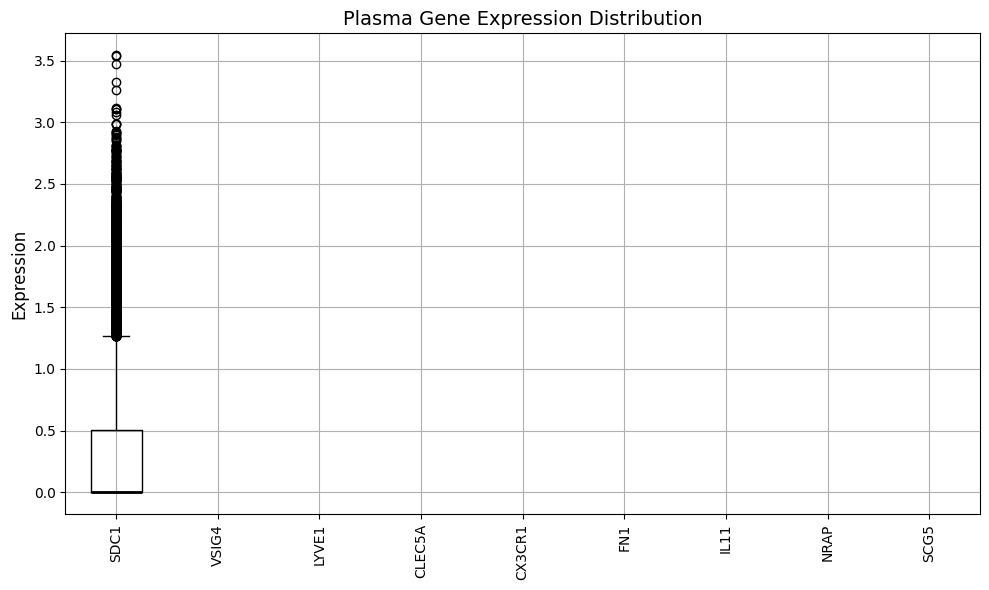

In [117]:
# 유전자별 발현 박스플롯 (검은색 박스/중앙선)
plt.figure(figsize=(10, 6))
ax = df.T.boxplot(
    vert=True,
    rot=90,
    boxprops=dict(color='black'),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', markeredgecolor='black', markerfacecolor='none')
)
plt.title("Plasma Gene Expression Distribution", fontsize=14)
plt.ylabel("Expression", fontsize=12)
plt.tight_layout()

plt.show()

In [118]:
# 2. 메타데이터 로드
meta_path = "/nas/arpa_h_repository/public_data/CRC_Atlas_1/CRC-Atlas-Split/crc-atlas/Deg_data/cellinfo_DA/cellinfo_DA_Plasma_cell_consensus.csv"
meta = pd.read_csv(meta_path, index_col="cell_name")  
meta
# index: cell_name, 컬럼 중 'Group_born'에 MSI/MSS 정보가 들어 있어요

,Group_born,Batch,Group
cell_name,,,
Borras_2023_KUL5_CD45Pos-EXT099-CATCGAAAGACAGAGA,MSS,Plasma cell,MSI_high
Borras_2023_SMC5-SMC200T-GGACAGACACCACGTG,MSI,Plasma cell,MSI_high
Borras_2023_SMC5-SMC234T-GTACTCCGTCCAGTAT,MSI,Plasma cell,MSI_high
Che_2021-SRR14710630-TTTGGTTCACGGTAAG,MSS,Plasma cell,MSS_high
Che_2021-SRR14710629-AAAGATGGTTTGACTG,MSS,Plasma cell,MSS_high
...,...,...,...
Zheng_2022-GSM4904239-TCTATTGGTAGCAAAT,MSS,Plasma cell,MSI_high
Zheng_2022-GSM4904239-TGGTTAGTCTAACCGA,MSS,Plasma cell,MSI_high
Zheng_2022-GSM4904240-AACCGCGTCCGTAGTA,MSS,Plasma cell,MSI_high


In [119]:
# 2) 전체 셀 개수
total_cells = meta.shape[0]

# 3) MSI vs MSS 셀 개수
group_counts = meta["Group_born"].value_counts()

print(f"전체 셀 개수: {total_cells}")
print("Group_born별 셀 개수:")
print(group_counts)

전체 셀 개수: 40512
Group_born별 셀 개수:
Group_born
MSS    32566
MSI     7946
Name: count, dtype: int64


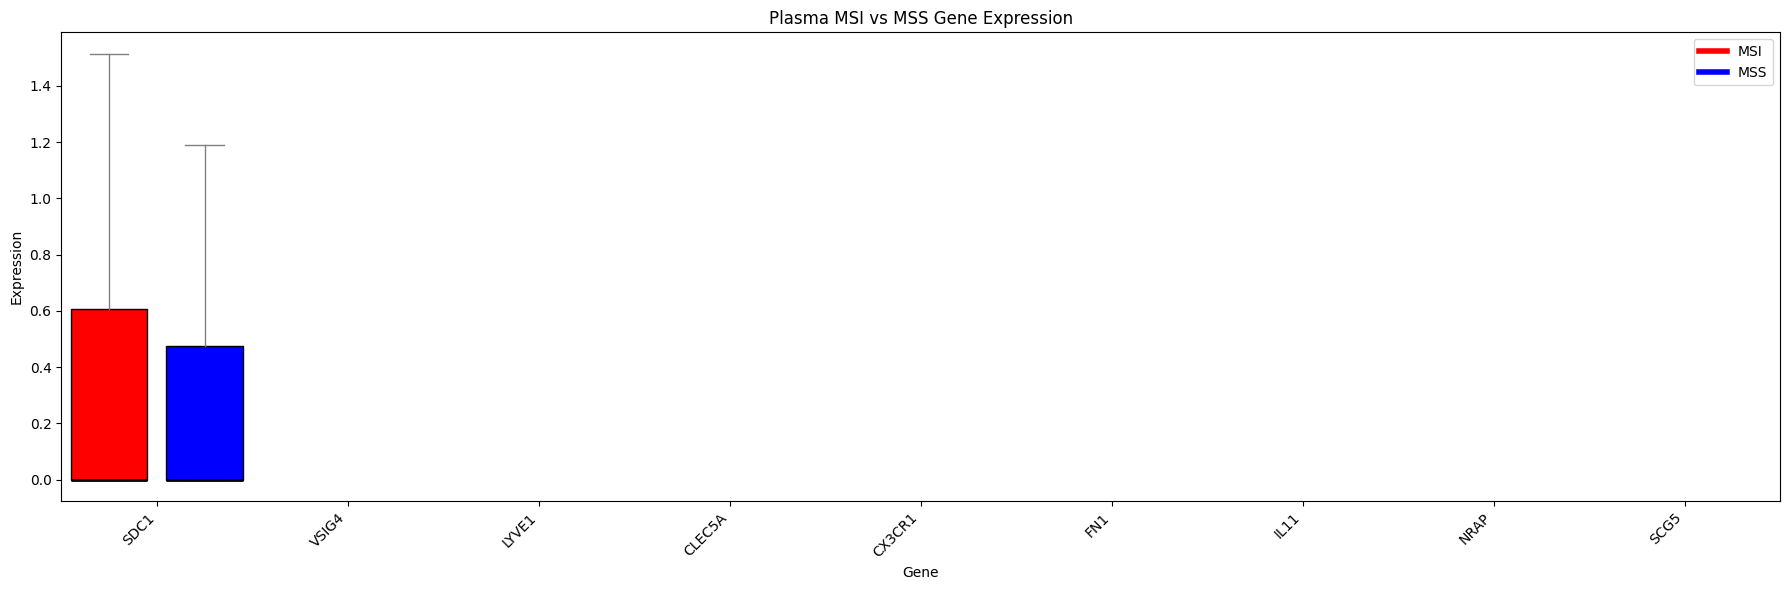

In [121]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# 2) MSI/MSS 셀 ID 분리
msi_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSI"])
mss_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSS"])

# 3) 유전자 리스트 (인덱스)
genes = df.index.tolist()

# 4) 데이터와 위치 설정
data = []
positions = []
labels = []  # for gene names at center

for i, gene in enumerate(genes):
    # 각 gene마다 MSI 데이터, MSS 데이터 추가
    data.append(df.loc[gene, msi_cells].dropna())
    data.append(df.loc[gene, mss_cells].dropna())
    # 위치: 2*i+1, 2*i+2
    positions.extend([2*i+1, 2*i+2])
    # gene label 위치 중앙(2*i+1.5)
    labels.append((2*i+1 + 2*i+2)/2)

# 5) 박스플롯
# plt.figure(figsize=(2*len(genes), 6))
# box = plt.boxplot(data,
#                   positions=positions,
#                   widths=0.8,
#                   patch_artist=True,
#                   showfliers=False)
# 5) 박스플롯 그리기 (medianprops 추가)
plt.figure(figsize=(2*len(genes), 6))
box = plt.boxplot(
    data,
    positions=positions,
    widths=0.8,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(color='gray'),
    capprops=dict(color='gray')
)

# 6) 색상 지정: MSI 빨강, MSS 파랑
for idx, patch in enumerate(box['boxes']):
    if idx % 2 == 0:      # 짝수 인덱스 → MSI
        patch.set_facecolor('red')
    else:                 # 홀수 인덱스 → MSS
        patch.set_facecolor('blue')

# x축 눈금: gene 이름을 중앙에
plt.xticks(labels, genes, rotation=45, ha='right')

# 8) 범례 추가
red_patch = plt.Line2D([0], [0], color='red', lw=4)
blue_patch = plt.Line2D([0], [0], color='blue', lw=4)
plt.legend([red_patch, blue_patch], ['MSI', 'MSS'], loc='upper right')

plt.xlabel("Gene")
plt.ylabel("Expression")
plt.title("Plasma MSI vs MSS Gene Expression")
        

plt.tight_layout()
plt.show()

## B cell

In [122]:
# 1. 데이터 로드
matrix_path = "/data/project/arpa_h/raw_data/split/9_genes_matrix/B_cell_filtered_matrix.csv"
df = pd.read_csv(matrix_path, index_col=0)  # Unnamed: 0 → gene names
df

,Borras_2023_SMC5-SMC145T-CACAGTAGTCAGCTAT,Che_2021-SRR14710630-AAACCTGGTTTGTTGG,Che_2021-SRR14710630-AAACGGGTCGCGTAGC,Che_2021-SRR14710630-AAAGATGGTCAAAGCG,Che_2021-SRR14710630-AACACGTCAGGGAGAG,Che_2021-SRR14710630-AACCGCGTCATAAAGG,Che_2021-SRR14710630-AACCGCGTCTGTTTGT,Che_2021-SRR14710630-AACTCTTCACGGACAA,Che_2021-SRR14710630-AACTCTTCATGAACCT,Che_2021-SRR14710630-AACTGGTGTGCGGTAA,...,Zheng_2022-GSM4904241-CGGAGTCAGTGGAGAA,Zheng_2022-GSM4904243-AAGTCTGAGCTAGTCT,Zheng_2022-GSM4904245-AAGGCAGCAGGTTTCA,Zheng_2022-GSM4904245-CCACGGACACACCGCA,Zheng_2022-GSM4904245-CGGCTAGCATAGTAAG,Zheng_2022-GSM4904245-GAAACTCAGGGAAACA,Zheng_2022-GSM4904245-GCCTCTAAGGCCGAAT,Zheng_2022-GSM4904245-TGGGCGTGTTGGTAAA,Zheng_2022-GSM4904245-TTGCCGTCATCCCATC,Zheng_2022-GSM4904246-GGGAATGCAGCGTTCG
VSIG4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LYVE1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CLEC5A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CX3CR1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FN1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
IL11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NRAP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SDC1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SCG5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [123]:
# Median 발현값
median_expr = df.median(axis=1, skipna=True)
median_expr

VSIG4    NaN
LYVE1    NaN
CLEC5A   NaN
CX3CR1   NaN
FN1      NaN
IL11     NaN
NRAP     NaN
SDC1     NaN
SCG5     NaN
dtype: float64

In [124]:
# mean 발현값
mean_expr = df.mean(axis=1, skipna=True)
mean_expr

VSIG4    NaN
LYVE1    NaN
CLEC5A   NaN
CX3CR1   NaN
FN1      NaN
IL11     NaN
NRAP     NaN
SDC1     NaN
SCG5     NaN
dtype: float64

In [125]:
# NaN을 0으로 치지 않고, 실제 0인 셀만 세기
zero_only = (df == 0)
zero_ratio = zero_only.sum(axis=1) / df.shape[1]
zero_ratio

VSIG4     0.0
LYVE1     0.0
CLEC5A    0.0
CX3CR1    0.0
FN1       0.0
IL11      0.0
NRAP      0.0
SDC1      0.0
SCG5      0.0
dtype: float64

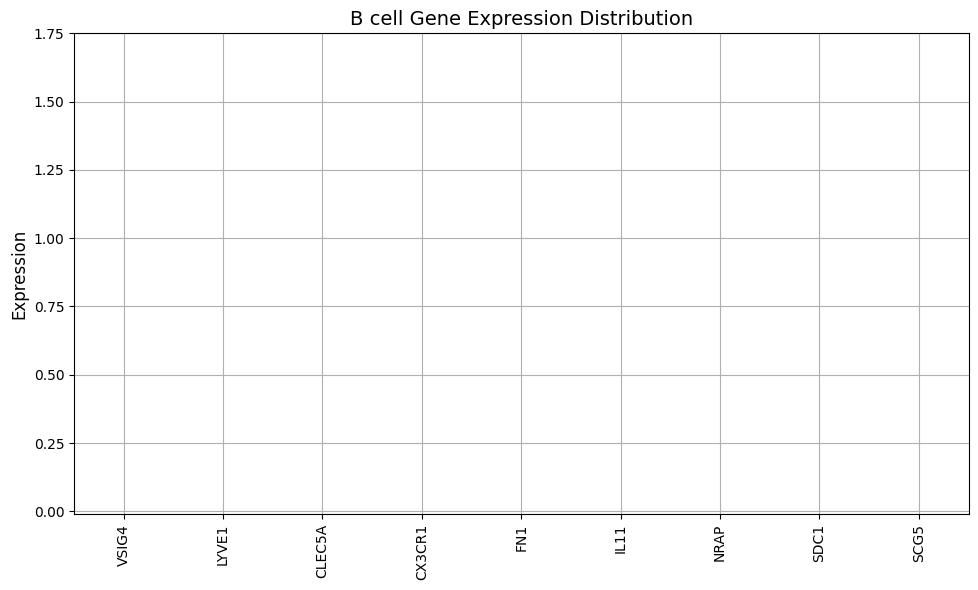

In [127]:
# 유전자별 발현 박스플롯 (검은색 박스/중앙선)
plt.figure(figsize=(10, 6))
ax = df.T.boxplot(
    vert=True,
    rot=90,
    boxprops=dict(color='black'),
    whiskerprops=dict(color='black'),
    capprops=dict(color='black'),
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='o', markeredgecolor='black', markerfacecolor='none')
)
plt.title("B cell Gene Expression Distribution", fontsize=14)
plt.ylabel("Expression", fontsize=12)
plt.tight_layout()
plt.ylim(-0.01, 1.75)
plt.yticks(np.arange(0, 1.75 + 0.001, 0.25))
plt.show()

In [128]:
# 2. 메타데이터 로드
meta_path = "/nas/arpa_h_repository/public_data/CRC_Atlas_1/CRC-Atlas-Split/crc-atlas/Deg_data/cellinfo_DA/cellinfo_DA_B_cell_consensus.csv"
meta = pd.read_csv(meta_path, index_col="cell_name")  
meta
# index: cell_name, 컬럼 중 'Group_born'에 MSI/MSS 정보가 들어 있어요

,Group_born,Batch,Group
cell_name,,,
Borras_2023_SMC5-SMC145T-CACAGTAGTCAGCTAT,MSS,B cell,MSI_high
Che_2021-SRR14710630-AAACCTGGTTTGTTGG,MSS,B cell,MSS_high
Che_2021-SRR14710630-AAACGGGTCGCGTAGC,MSS,B cell,MSS_high
Che_2021-SRR14710630-AAAGATGGTCAAAGCG,MSS,B cell,MSS_high
Che_2021-SRR14710630-AACACGTCAGGGAGAG,MSS,B cell,MSS_high
...,...,...,...
Zheng_2022-GSM4904245-GAAACTCAGGGAAACA,MSS,B cell,MSS_high
Zheng_2022-GSM4904245-GCCTCTAAGGCCGAAT,MSS,B cell,MSS_high
Zheng_2022-GSM4904245-TGGGCGTGTTGGTAAA,MSS,B cell,MSS_high


In [129]:
# 2) 전체 셀 개수
total_cells = meta.shape[0]

# 3) MSI vs MSS 셀 개수
group_counts = meta["Group_born"].value_counts()

print(f"전체 셀 개수: {total_cells}")
print("Group_born별 셀 개수:")
print(group_counts)

전체 셀 개수: 33844
Group_born별 셀 개수:
Group_born
MSS    20405
MSI    13439
Name: count, dtype: int64


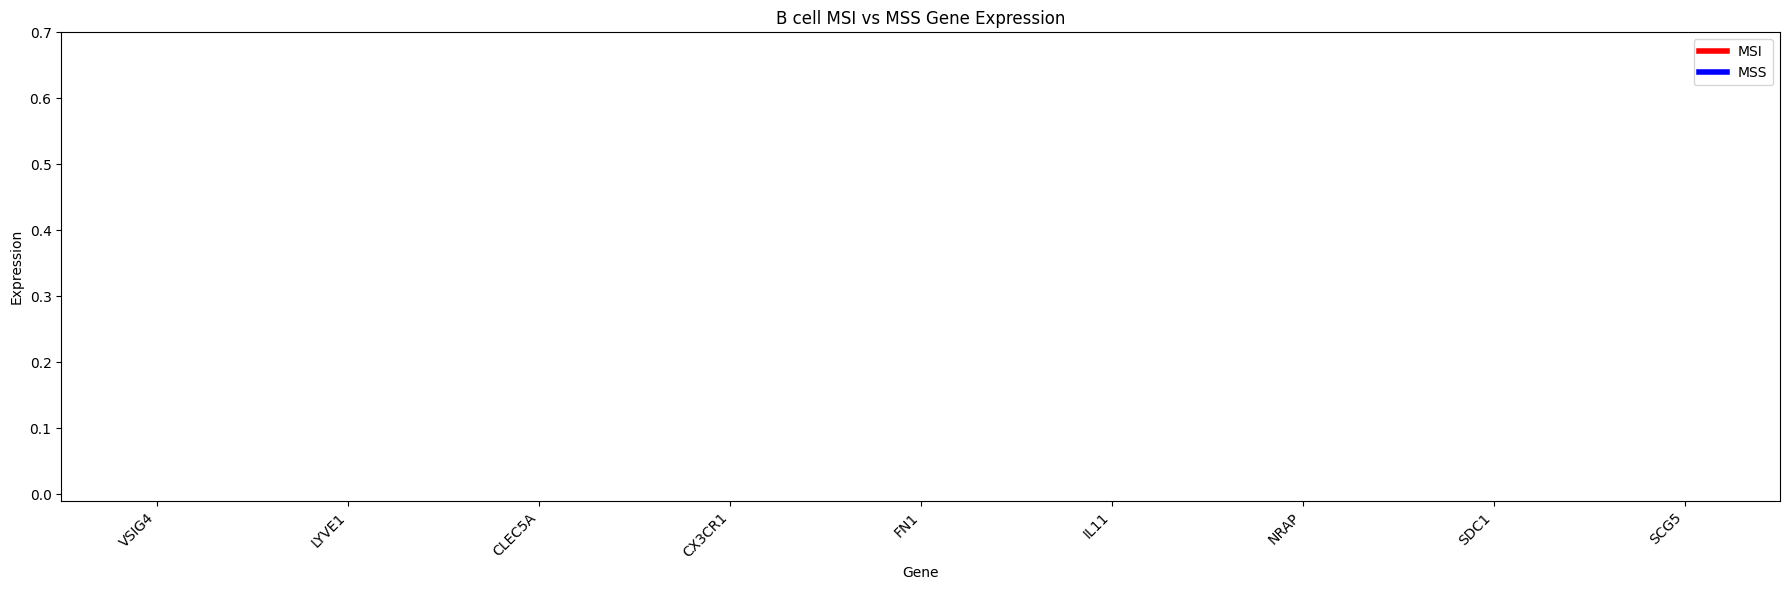

In [131]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# 2) MSI/MSS 셀 ID 분리
msi_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSI"])
mss_cells = df.columns.intersection(meta.index[meta["Group_born"] == "MSS"])

# 3) 유전자 리스트 (인덱스)
genes = df.index.tolist()

# 4) 데이터와 위치 설정
data = []
positions = []
labels = []  # for gene names at center

for i, gene in enumerate(genes):
    # 각 gene마다 MSI 데이터, MSS 데이터 추가
    data.append(df.loc[gene, msi_cells].dropna())
    data.append(df.loc[gene, mss_cells].dropna())
    # 위치: 2*i+1, 2*i+2
    positions.extend([2*i+1, 2*i+2])
    # gene label 위치 중앙(2*i+1.5)
    labels.append((2*i+1 + 2*i+2)/2)

# 5) 박스플롯
# plt.figure(figsize=(2*len(genes), 6))
# box = plt.boxplot(data,
#                   positions=positions,
#                   widths=0.8,
#                   patch_artist=True,
#                   showfliers=False)
# 5) 박스플롯 그리기 (medianprops 추가)
plt.figure(figsize=(2*len(genes), 6))
box = plt.boxplot(
    data,
    positions=positions,
    widths=0.8,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(color='gray'),
    capprops=dict(color='gray')
)

# 6) 색상 지정: MSI 빨강, MSS 파랑
for idx, patch in enumerate(box['boxes']):
    if idx % 2 == 0:      # 짝수 인덱스 → MSI
        patch.set_facecolor('red')
    else:                 # 홀수 인덱스 → MSS
        patch.set_facecolor('blue')

# x축 눈금: gene 이름을 중앙에
plt.xticks(labels, genes, rotation=45, ha='right')

# 8) 범례 추가
red_patch = plt.Line2D([0], [0], color='red', lw=4)
blue_patch = plt.Line2D([0], [0], color='blue', lw=4)
plt.legend([red_patch, blue_patch], ['MSI', 'MSS'], loc='upper right')

plt.xlabel("Gene")
plt.ylabel("Expression")
plt.title("B cell MSI vs MSS Gene Expression")
        
plt.ylim(-0.01, 0.7)
plt.tight_layout()
plt.show()